In [39]:
"""
pareto_results.py — Pareto Front Preliminary Results
=====================================================
Generates all figures for the preliminary results section of the
Pareto front analysis.  Reads the three CSVs produced by batch_sweep.py.

Required input files
--------------------
    pareto_summary.csv  — one row per (α, β, γ, N_A) combination
    run_summary.csv     — one row per individual simulation run
    raw_runs.csv        — one row per (run, timestep)

Output figures
--------------
    01_strategy_classification.png  — K-means clusters on Pareto front
    02_tradeoff_matrix.png          — pairwise objective trade-off matrix
    03_phase_heatmaps_<obj>.png     — α×β phase diagrams (one file per objective)
    04_<obj>.png                    — per-objective deep-dive (one file per objective)
    05_two_objective_pareto.png     — reduced 2D Pareto (Fitness vs Dissipation)
    06_convergence.png              — consensus / multi-objective convergence
    gamma_t_symmetry.png            - gamma ±0.1 symmetry proof (t-tests + Bonferroni correction)

Usage
-----
    python pareto_results.py
"""

from __future__ import annotations

import math
import pathlib
import warnings

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
PARETO_CSV = "results/final-data/pareto_summary.csv"
SUMM_CSV   = "results/final-data/run_summary.csv"
RAW_CSV    = "results/final-data/raw_runs.csv"
PLOT_DIR   = "results/final-data/pareto_results"

LAMBDA_META  = 5.0
LAMBDA_NECRO = 1.0
LAMBDA_FIT   = 0.01

N_STRATEGIES    = 4
STRATEGY_NAMES  = ["Efficient", "Invasive", "Necrotic", "Explosive"]
STRATEGY_COLORS = ["#2ecc71",   "#e74c3c",  "#9b59b6",  "#f39c12"]
STRATEGY_MARKS  = ["o",         "^",        "s",        "D"]

# (run_col, pf_mean_col, display_label, colour, maximise?)
OBJ_META = [
    ("fitness",     "mean_fitness",     "Fitness",     "#00e5a0", True),
    ("mei",         "mean_mei",         "MEI",         "#f0a030", False),
    ("ncf",         "mean_ncf",         "NCF",         "#b57bee", False),
    ("dissipation", "mean_dissipation", "Dissipation", "#4da6ff", False),
]
OBJECTIVES = [m[0] for m in OBJ_META]
OBJ_COLS   = [m[1] for m in OBJ_META]
OBJ_LABELS = [m[2] for m in OBJ_META]
OBJ_COLORS = [m[3] for m in OBJ_META]

# statistical testing parameters
N_RUNS      = 100                        # runs per combo
DF          = 2 * N_RUNS - 2             # Welch approx. ≈ 198
ALPHA_FW    = 0.05                       # desired family-wise error rate
# NOTE: N_COMBOS / N_TESTS are NOT hardcoded here anymore — they depend on
# how many (alpha, beta, n_a) triples actually carry both gamma=+0.1 and
# gamma=-0.1 in the data, which changes with the sweep design. They are
# computed dynamically inside fig_additional_gamma() from len(t_data).

# general parameters
PARAM_KEYS   = ["alpha", "beta", "gamma", "n_a"]
PARAM_LABELS = {
    "alpha": "α (death rate)",
    "beta":  "β (growth rate)",
    "gamma": "γ (phenotype)",
    "n_a":   "N_A (angio. threshold)",
}
PARAM_META = [(k, PARAM_LABELS[k]) for k in PARAM_KEYS]

# ─────────────────────────────────────────────────────────────────────────────
#  STYLE
# ─────────────────────────────────────────────────────────────────────────────
BG  = "#0a0e14"
PAN = "#111820"
EDG = "#1e2a35"
TXT = "#d4e0ec"
DIM = "#6b7d8f"
GRD = "#1a2535"

plt.rcParams.update({
    "figure.facecolor": BG,  "axes.facecolor":  PAN,
    "axes.edgecolor":   EDG, "axes.labelcolor": TXT,
    "axes.titlecolor":  TXT, "xtick.color":     DIM,
    "ytick.color":      DIM, "grid.color":      GRD,
    "grid.linewidth":   0.5, "text.color":      TXT,
    "legend.facecolor": PAN, "legend.edgecolor": EDG,
    "legend.labelcolor":TXT, "figure.dpi":      130,
    "font.family":      "DejaVu Sans", "font.size": 9,
    "axes.titlesize":   10,  "axes.labelsize":   9,
    "axes.titlepad":    7,
})

In [40]:
def _save(fig, name: str):
    display(fig)
    path = pathlib.Path(PLOT_DIR) / name
    fig.savefig(path, dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    print(f"  Saved {path}")


def _panel(ax, title: str, grid: bool = True):
    ax.set_title(title, fontsize=9, pad=5)
    if grid:
        ax.grid(True, alpha=0.3, lw=0.5)


def _pearson_r(x, y) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    return float(np.corrcoef(x[mask], y[mask])[0, 1]) if mask.sum() >= 3 else float("nan")


# ─────────────────────────────────────────────────────────────────────────────
#  DATA LOADING
# ─────────────────────────────────────────────────────────────────────────────
def load_data():
    print("Loading data …")
    pf  = pd.read_csv(PARETO_CSV)
    run = pd.read_csv(SUMM_CSV)

    # Back-compat: fill missing sweep params with defaults
    for df in (pf, run):
        for col, default in [("gamma", 0.0), ("n_a", 500)]:
            if col not in df.columns:
                df[col] = default

    # Recompute dissipation if missing
    if "dissipation" not in run.columns:
        run["tumor_radius"] = run["final_total"].apply(
            lambda n: max(1.0, (3 * n / (4 * math.pi)) ** (1 / 3))
        )
        run["dissipation"] = (
            run["tumor_radius"] ** 2
            * (1 + LAMBDA_NECRO * run["ncf"])
            * (1 + LAMBDA_META  * run["mei"])
        )
    else:
        run["tumor_radius"] = run["final_total"].apply(
            lambda n: max(1.0, (3 * n / (4 * math.pi)) ** (1 / 3))
        )

    # Non-redundant alternative efficiency scores (per run)
    run["E_A"] = run["final_alive"] / (
        run["tumor_radius"] ** 2 * run["total_oxygen_consumed"].clip(1e-6)
    )
    run["E_B"] = run["fitness"] / run["tumor_radius"].clip(1e-6) ** 2

    run_ok = run[run["status"] == "ok"]

    # Aggregate alternatives into pareto_summary
    alt = run_ok.groupby(PARAM_KEYS).agg(
        mean_E_A=("E_A", "mean"),
        mean_E_B=("E_B", "mean"),
        mean_radius=("tumor_radius", "mean"),
    ).reset_index()
    pf = pf.merge(alt, on=PARAM_KEYS, how="left")

    front = pf[pf["pareto_front"] == True].copy().reset_index(drop=True)
    print(f"  pareto_summary : {len(pf):,} rows  ({len(front)} on Pareto front)")
    print(f"  run_summary    : {len(run):,} rows  ({len(run_ok):,} ok)")
    return pf, run, front, run_ok

# ─────────────────────────────────────────────────────────────────────────────
#  LOAD & COMPUTE T-STATISTICS
# ─────────────────────────────────────────────────────────────────────────────
def load_data_t_stats():
    df = pd.read_csv(PARETO_CSV)
    df = df[['alpha', 'beta', 'gamma', 'n_a', 'n_ok',
            'mean_fitness',     'std_fitness',
            'mean_mei',         'std_mei',
            'mean_ncf',         'std_ncf',
            'mean_dissipation', 'std_dissipation']]

    pivot_df = (
        df[df["gamma"] != 0]
        .pivot(
            index=["alpha", "beta", "n_a"],
            columns="gamma",
            values=[f'{s}_{o}' for s in ('mean', 'std') for o in OBJECTIVES],
        )
    )

    for obj in OBJECTIVES:
        mean_pos = pivot_df[(f'mean_{obj}',  0.1)]
        mean_neg = pivot_df[(f'mean_{obj}', -0.1)]
        std_pos  = pivot_df[(f'std_{obj}',   0.1)]
        std_neg  = pivot_df[(f'std_{obj}',  -0.1)]
        # Welch standard error: sqrt(s1²/n + s2²/n)
        se       = np.sqrt((std_pos**2 + std_neg**2) / N_RUNS)
        pivot_df[f't_{obj}'] = (mean_pos - mean_neg).abs() / se

    t_data = pivot_df[[f't_{obj}' for obj in OBJECTIVES]].copy()
    t_data.columns = OBJECTIVES
    return t_data

# ─────────────────────────────────────────────────────────────────────────────
#  STRATEGY CLUSTERING  (used by Fig 01 and Fig 03)
# ─────────────────────────────────────────────────────────────────────────────

In [41]:
def _label_clusters(front: pd.DataFrame):
    X  = front[OBJ_COLS].fillna(0).values
    Xn = MinMaxScaler().fit_transform(X)
    km = KMeans(n_clusters=N_STRATEGIES, n_init=20, random_state=42)
    raw_labels = km.fit_predict(Xn)
    centres_n  = km.cluster_centers_
    centres    = MinMaxScaler().fit(X).inverse_transform(centres_n)

    # Map raw cluster indices to named strategies by which objective is extreme
    slot_spec = [
        ("fitness",     -1),   # Efficient  → highest fitness
        ("mei",         +1),   # Invasive   → highest MEI
        ("ncf",         +1),   # Necrotic   → highest NCF
        ("dissipation", +1),   # Explosive  → highest dissipation
    ]
    col_idx   = {m[0]: i for i, m in enumerate(OBJ_META)}
    cluster_map, assigned = {}, set()
    for slot, (col, sign) in enumerate(slot_spec):
        ci = col_idx[col]
        for cid in np.argsort(sign * centres[:, ci]):
            if cid not in assigned:
                cluster_map[cid] = slot
                assigned.add(cid)
                break

    return np.array([cluster_map[c] for c in raw_labels])


def assign_strategies(front: pd.DataFrame) -> pd.DataFrame:
    if len(front) < N_STRATEGIES:
        front = front.copy()
        front["strategy"]       = 0
        front["strategy_name"]  = STRATEGY_NAMES[0]
        front["strategy_color"] = STRATEGY_COLORS[0]
        front["strategy_mark"]  = STRATEGY_MARKS[0]
        return front
    labels = _label_clusters(front)
    front  = front.copy()
    front["strategy"]       = labels
    front["strategy_name"]  = [STRATEGY_NAMES[l]  for l in labels]
    front["strategy_color"] = [STRATEGY_COLORS[l] for l in labels]
    front["strategy_mark"]  = [STRATEGY_MARKS[l]  for l in labels]
    return front


def _scatter_by_strategy(ax, front, xcol, ycol, size=55, alpha=0.85):
    for s_idx, name in enumerate(STRATEGY_NAMES):
        sub = front[front["strategy"] == s_idx]
        if sub.empty:
            continue
        ax.scatter(sub[xcol], sub[ycol],
                   c=STRATEGY_COLORS[s_idx], marker=STRATEGY_MARKS[s_idx],
                   s=size, alpha=alpha, label=name, edgecolors="none", zorder=3)


def _strategy_legend_handles():
    return [mpatches.Patch(color=STRATEGY_COLORS[i], label=STRATEGY_NAMES[i])
            for i in range(N_STRATEGIES)]

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 01 — STRATEGY CLASSIFICATION
# ─────────────────────────────────────────────────────────────────────────────

In [42]:
def fig01_strategy_classification(front: pd.DataFrame):
    """
    Three pairwise scatter panels (Fitness vs MEI, Fitness vs NCF, MEI vs NCF)
    coloured by K-means cluster.  Identifies four qualitative growth modes on
    the Pareto front: Efficient, Invasive, Necrotic, Explosive.
    """
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle("Pareto Front — Strategy Classification",
                 fontsize=13, color=TXT, y=1.01)

    pairs   = [("mean_fitness","mean_mei"),
               ("mean_fitness","mean_ncf"),
               ("mean_mei",   "mean_ncf")]
    xlabels = ["Fitness", "Fitness", "MEI"]
    ylabels = ["MEI",     "NCF",     "NCF"]

    axes = fig.subplots(1, 3)
    for ax, (xc, yc), xl, yl in zip(axes, pairs, xlabels, ylabels):
        _scatter_by_strategy(ax, front, xc, yc)
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        _panel(ax, f"{xl} vs {yl}")

    fig.legend(handles=_strategy_legend_handles(),
               loc="lower center", ncol=N_STRATEGIES,
               bbox_to_anchor=(0.5, -0.07), framealpha=0.4, fontsize=9)

    # Strategy description table below figure
    descriptions = [
        ("Efficient",  "High fitness, low MEI/NCF/Dissipation — best biomass yield per O₂ unit"),
        ("Invasive",   "High MEI — aggressive metastatic spread relative to final population"),
        ("Necrotic",   "High NCF — large necrotic core, insufficient oxygen delivery to interior"),
        ("Explosive",  "High Dissipation — fast volumetric growth, high energetic cost"),
    ]
    y0 = -0.22
    for i, (name, desc) in enumerate(descriptions):
        fig.text(0.02, y0 - i * 0.055, f"  {name}",
                 fontsize=8.5, color=STRATEGY_COLORS[i], fontweight="bold",
                 transform=fig.transFigure)
        fig.text(0.13, y0 - i * 0.055, desc,
                 fontsize=8.5, color=DIM, transform=fig.transFigure)

    plt.tight_layout()
    _save(fig, "01_strategy_classification.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 02 — PAIRWISE TRADE-OFF MATRIX
# ─────────────────────────────────────────────────────────────────────────────

In [43]:
def fig02_tradeoff_matrix(front: pd.DataFrame):
    """
    4×4 matrix of all objective pairs.
      Diagonal     : per-strategy histograms (distribution of each objective)
      Lower triangle: scatter plots coloured by strategy
      Upper triangle: Pearson r annotation (green = positive, red = negative)
    """
    n   = len(OBJ_COLS)
    fig, axes = plt.subplots(n, n, figsize=(13, 12))
    fig.suptitle("Pairwise Objective Trade-offs — Pareto Front",
                 fontsize=12, color=TXT, y=1.01)

    for row in range(n):
        for col in range(n):
            ax = axes[row][col]
            if row == col:
                # Diagonal: distribution per strategy
                for s_idx, name in enumerate(STRATEGY_NAMES):
                    sub = front[front["strategy"] == s_idx]
                    if not sub.empty:
                        ax.hist(sub[OBJ_COLS[row]], bins=8, alpha=0.55,
                                color=STRATEGY_COLORS[s_idx], density=True)
                ax.set_xlabel(OBJ_LABELS[row], fontsize=8)
                ax.set_yticks([])
            elif row > col:
                # Lower triangle: strategy-coloured scatter
                _scatter_by_strategy(ax, front, OBJ_COLS[col], OBJ_COLS[row], size=40)
                ax.set_xlabel(OBJ_LABELS[col], fontsize=8)
                ax.set_ylabel(OBJ_LABELS[row], fontsize=8)
                ax.grid(True, alpha=0.2)
            else:
                # Upper triangle: Pearson r value
                r = _pearson_r(front[OBJ_COLS[col]].values,
                               front[OBJ_COLS[row]].values)
                color = "#e74c3c" if r < -0.3 else "#2ecc71" if r > 0.3 else DIM
                ax.text(0.5, 0.5, f"r = {r:+.2f}", ha="center", va="center",
                        fontsize=14, color=color, fontweight="bold",
                        transform=ax.transAxes)
                ax.set_xlabel(OBJ_LABELS[col], fontsize=8)
                ax.set_ylabel(OBJ_LABELS[row], fontsize=8)
                ax.set_facecolor(BG)

            ax.tick_params(labelsize=7)

    fig.legend(handles=_strategy_legend_handles(),
               loc="lower center", ncol=N_STRATEGIES,
               bbox_to_anchor=(0.5, -0.03), framealpha=0.4, fontsize=9)
    plt.tight_layout()
    _save(fig, "02_tradeoff_matrix.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 03 — PHASE HEATMAPS  (one file per objective)
# ─────────────────────────────────────────────────────────────────────────────

In [44]:
def fig03_phase_heatmaps(pf: pd.DataFrame):
    """
    For each objective: a grid of α×β heatmaps, one panel per (γ, N_A) pair.
    Colour scale is global (same across all panels within a figure) so values
    are comparable.  The optimal cell is outlined in white.
    """
    gamma_vals = sorted(pf["gamma"].unique())
    na_vals    = sorted(pf["n_a"].unique())
    nrow, ncol = len(gamma_vals), len(na_vals)

    cmap_per_obj = {
        "mean_fitness":     ("YlOrRd",  True),   # bright = high = good
        "mean_mei":         ("Blues_r", False),   # bright = low  = good
        "mean_ncf":         ("Purples_r", False),
        "mean_dissipation": ("hot_r",   False),
    }

    for run_col, pf_col, label, color, maximise in OBJ_META:
        if pf_col not in pf.columns:
            print(f"  Skipping phase heatmap for {label} (column missing)")
            continue

        cmap, _ = cmap_per_obj.get(pf_col, ("viridis", maximise))
        vmin    = pf[pf_col].min()
        vmax    = pf[pf_col].max()

        fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4 * nrow))
        fig.suptitle(
            f"Phase Diagram — {label}  ({'↑ maximise' if maximise else '↓ minimise'})\n"
            f"α vs β for each (γ, N_A) combination",
            fontsize=12, color=TXT, y=1.01,
        )

        # Normalise axes to always be indexable as [row][col]
        if nrow == 1 and ncol == 1:
            axes_2d = [[axes]]
        elif nrow == 1:
            axes_2d = [axes]
        elif ncol == 1:
            axes_2d = [[ax] for ax in axes]
        else:
            axes_2d = axes

        for ri, gamma in enumerate(gamma_vals):
            for ci, na in enumerate(na_vals):
                ax  = axes_2d[ri][ci]
                sub = pf[(pf["gamma"] == gamma) & (pf["n_a"] == na)]

                if sub.empty:
                    ax.set_visible(False)
                    continue

                pivot = sub.pivot_table(index="alpha", columns="beta",
                                        values=pf_col, aggfunc="mean")
                im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                               vmin=vmin, vmax=vmax, origin="lower",
                               interpolation="nearest")
                ax.set_xticks(range(len(pivot.columns)))
                ax.set_yticks(range(len(pivot.index)))
                ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns], fontsize=7)
                ax.set_yticklabels([f"{v:.2f}" for v in pivot.index],   fontsize=7)
                ax.set_xlabel("β (growth)", fontsize=8)
                ax.set_ylabel("α (death)",  fontsize=8)
                ax.set_title(f"γ={gamma}, N_A={int(na)}", fontsize=9)

                # Value annotations
                for (r, c), val in np.ndenumerate(pivot.values):
                    if np.isfinite(val):
                        ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                                fontsize=6.5, color="white",
                                bbox=dict(boxstyle="round,pad=0.1",
                                          fc="black", alpha=0.3))

                # Outline optimal cell
                best_idx = (np.nanargmax(pivot.values) if maximise
                            else np.nanargmin(pivot.values))
                r_idx, c_idx = np.unravel_index(best_idx, pivot.values.shape)
                ax.add_patch(plt.Rectangle(
                    (c_idx - 0.5, r_idx - 0.5), 1, 1,
                    fill=False, edgecolor="white", lw=2, zorder=4,
                ))

        # Shared colour bar
        fig.subplots_adjust(right=0.88)
        cax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
        sm  = ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
        sm.set_array([])
        fig.colorbar(sm, cax=cax, label=label)

        _save(fig, f"03_phase_heatmaps_{run_col}.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 04 — PER-OBJECTIVE DEEP-DIVE
# ─────────────────────────────────────────────────────────────────────────────

In [45]:
def _per_objective_figure(
    run_col: str, pf_col: str, label: str, color: str, maximise: bool,
    pf: pd.DataFrame, front: pd.DataFrame, run_ok: pd.DataFrame,
    savename: str,
):
    """
    Six-panel analysis for a single objective:

      A — Violin distributions grouped by α value
      B — α vs β phase heatmap (pooled over γ, N_A)
      C — Marginal sensitivity: mean objective vs each parameter on one axis
      D — Pearson r with every other objective (bar chart)
      E — Top-10 parameter combinations ranked by this objective (table)
      F — Time-evolution proxy: best vs worst parameter pair from raw_runs
    """
    direction = "↑ maximise" if maximise else "↓ minimise"

    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        f"Individual Objective Analysis — {label}  ({direction})",
        fontsize=12, color=TXT, y=1.01,
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    # ── A: Violin distributions by α ─────────────────────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    if pf_col in front.columns:
        alpha_vals = sorted(front["beta"].unique())
        data       = [front[front["beta"] == a][pf_col].dropna().values
                      for a in alpha_vals]
        parts = ax.violinplot(data, positions=range(len(alpha_vals)),
                              showmedians=True, showextrema=True)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.55)
            pc.set_edgecolor(EDG)
        for k in ("cmedians", "cbars", "cmins", "cmaxes"):
            if k in parts:
                parts[k].set_edgecolor("white")
                parts[k].set_linewidth(1.2)
        ax.set_xticks(range(len(alpha_vals)))
        ax.set_xticklabels([f"α={a}" for a in alpha_vals], fontsize=8)
        ax.set_ylabel(label)
        best = front[pf_col].max() if maximise else front[pf_col].min()
        ax.axhline(best, color=color, lw=1, ls=":", alpha=0.6,
                   label=f"Best = {best:.4f}")
        ax.legend(fontsize=7.5, framealpha=0.4)
    _panel(ax, f"A — {label} Distribution by beta")

    # ── B: α vs β phase heatmap (pool γ, N_A) ────────────────────────────────
    ax = fig.add_subplot(gs[0, 1])
    if pf_col in pf.columns:
        pivot = pf.pivot_table(index="alpha", columns="beta",
                               values=pf_col, aggfunc="mean")
        cmap  = "RdYlGn" if maximise else "RdYlGn_r"
        im    = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                          origin="lower", interpolation="nearest")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels([f"{v:.2f}" for v in pivot.columns], fontsize=7)
        ax.set_yticklabels([f"{v:.2f}" for v in pivot.index],   fontsize=7)
        ax.set_xlabel("β (growth)")
        ax.set_ylabel("α (death)")
        plt.colorbar(im, ax=ax, label=label, fraction=0.046, pad=0.04)
        # Outline best cell
        best_idx = (np.nanargmax(pivot.values) if maximise
                    else np.nanargmin(pivot.values))
        r_idx, c_idx = np.unravel_index(best_idx, pivot.values.shape)
        ax.add_patch(plt.Rectangle(
            (c_idx - 0.5, r_idx - 0.5), 1, 1,
            fill=False, edgecolor="white", lw=2, zorder=4,
        ))
    _panel(ax, "B — α vs β Phase Map  (pooled γ, N_A)", grid=False)

    # ── C: Marginal sensitivity across all four parameters ────────────────────
    ax = fig.add_subplot(gs[0, 2])
    param_items = [(p, PARAM_LABELS[p]) for p in PARAM_KEYS if p in pf.columns]
    if pf_col in pf.columns:
        offsets = np.linspace(-0.03, 0.03, len(param_items))
        for (pcol, plabel), offset in zip(param_items, offsets):
            gm = pf.groupby(pcol)[pf_col].mean()
            xv = gm.index.values.astype(float)
            xn = (xv - xv.min()) / (np.ptp(xv) + 1e-12)
            c_p = plt.cm.tab10(param_items.index((pcol, plabel)))
            ax.plot(xn + offset, gm.values, lw=1.8, marker="o", ms=5,
                    color=c_p, label=plabel, alpha=0.85)
        ax.set_xlabel("Normalised parameter value →")
        ax.set_ylabel(label)
        ax.legend(fontsize=7.5, framealpha=0.4, loc="best")
    _panel(ax, f"C — Marginal Sensitivity of {label}")

    # ── D: Correlation with other objectives ──────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    other_objs = [(rc, pc, lb, cl) for rc, pc, lb, cl, _ in OBJ_META
                  if pc != pf_col and pc in front.columns]
    if pf_col in front.columns and other_objs:
        for i, (_, opc, olb, ocl) in enumerate(other_objs):
            r     = _pearson_r(front[pf_col].values, front[opc].values)
            bar_c = ocl if abs(r) > 0.3 else DIM
            b     = ax.bar(i, r, color=bar_c, alpha=0.85, width=0.6)
            ax.bar_label(b, fmt="%.3f", fontsize=8.5, color=TXT, padding=2)
        ax.set_xticks(range(len(other_objs)))
        ax.set_xticklabels([olb for _, _, olb, _ in other_objs], fontsize=9)
        ax.axhline(0,    color=DIM, lw=0.8)
        ax.axhline( 0.5, color=DIM, lw=0.6, ls=":", alpha=0.5)
        ax.axhline(-0.5, color=DIM, lw=0.6, ls=":", alpha=0.5)
        ax.set_ylabel(f"Pearson r  with  {label}")
        ax.set_ylim(-1.1, 1.1)
    _panel(ax, f"D — Correlation of {label} with Other Objectives")

    # ── E: Top-10 parameter pairs table ──────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    ax.axis("off")
    if pf_col in front.columns:
        top10 = (front.nlargest(10, pf_col) if maximise
                 else front.nsmallest(10, pf_col))
        present_objs = [m for m in OBJ_META if m[1] in front.columns]
        col_hdr  = ["Rank", "α", "β", "γ", "N_A"] + [m[2] for m in present_objs]
        tbl_data = []
        for rank, (_, r) in enumerate(top10.iterrows(), 1):
            row_vals = [rank, r.alpha, r.beta, r.gamma, int(r.n_a)]
            for m in present_objs:
                row_vals.append(f"{r[m[1]]:.4f}")
            tbl_data.append(row_vals)
        tbl = ax.table(cellText=tbl_data, colLabels=col_hdr,
                       cellLoc="center", loc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(7)
        tbl.scale(1, 1.4)
        # Highlight focal-objective column header
        focal_col_idx = col_hdr.index(label) if label in col_hdr else None
        for (row_i, col_i), cell in tbl.get_celld().items():
            cell.set_facecolor(BG if row_i == 0 else PAN)
            cell.set_edgecolor(EDG)
            if row_i == 0 and col_i == focal_col_idx:
                cell.set_facecolor(color + "55")
            cell.set_text_props(color=color if row_i == 0 else TXT)
    _panel(ax, f"E — Top-10 Pairs by {label}  ({'max' if maximise else 'min'})",
           grid=False)

    # ── F: Time-evolution proxy ───────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 2])
    raw_col_map = {
        "mean_fitness":     ("avg_b",             "⟨b⟩  (division probability)"),
        "mean_mei":         ("metastatic_cells",  "Metastatic events / step"),
        "mean_ncf":         ("avg_C",             "⟨C⟩  (hypoxia proxy)"),
        "mean_dissipation": ("population",        "Population N(t)"),
    }
    raw_col, proxy_label = raw_col_map.get(pf_col, (None, ""))

    try:
        raw = pd.read_csv(RAW_CSV)
        for col, default in [("gamma", 0.0), ("n_a", 500)]:
            if col not in raw.columns:
                raw[col] = default

        if pf_col in front.columns and raw_col and raw_col in raw.columns:
            best_row  = (front.nlargest(1, pf_col) if maximise
                         else front.nsmallest(1, pf_col)).iloc[0]
            worst_row = (front.nsmallest(1, pf_col) if maximise
                         else front.nlargest(1, pf_col)).iloc[0]

            for row_p, lbl, lcolor, ls in [
                (best_row,  "Best",  color,    "-"),
                (worst_row, "Worst", "#e05555", "--"),
            ]:
                mask = pd.Series([True] * len(raw))
                for k in PARAM_KEYS:
                    mask &= (raw[k] == row_p[k])
                sub  = raw[mask].groupby("sim_time")[raw_col]
                gm   = sub.mean()
                gs_  = sub.std().fillna(0)
                t    = gm.index.values
                ax.plot(t, gm.values, color=lcolor, lw=2, ls=ls,
                        label=f"{lbl}  (α={row_p.alpha}, β={row_p.beta})")
                ax.fill_between(t, gm - gs_, gm + gs_,
                                color=lcolor, alpha=0.12)
            ax.set_xlabel("Simulation time")
            ax.set_ylabel(proxy_label)
            ax.legend(fontsize=7.5, framealpha=0.4)
    except FileNotFoundError:
        ax.text(0.5, 0.5, "raw_runs.csv not found",
                ha="center", va="center",
                transform=ax.transAxes, color=DIM)

    _panel(ax, f"F — Time-Evolution Proxy for {label}\n(best vs worst pair)")

    plt.tight_layout()
    _save(fig, savename)


def fig_A01_to_A04(pf, front, run_ok):
    """Loop over all four objectives and produce A01–A04."""
    tags = {
        "mean_fitness":     "04_fitness.png",
        "mean_mei":         "04_mei.png",
        "mean_ncf":         "04_ncf.png",
        "mean_dissipation": "04_dissipation.png",
    }
    for run_col, pf_col, label, color, maximise in OBJ_META:
        savename = tags[pf_col]
        print(f"    {savename} …")
        _per_objective_figure(run_col, pf_col, label, color, maximise,
                              pf, front, run_ok, savename)

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 05 — REDUCED 2D PARETO: FITNESS vs DISSIPATION
# ─────────────────────────────────────────────────────────────────────────────

In [46]:
def fig_A05_two_objective_pareto(front: pd.DataFrame):
    """
    Since MEI and NCF are algebraically embedded in Dissipation, the only
    truly independent Pareto trade-off is Fitness vs Dissipation.

      A — Full scatter with 2D front highlighted and utopia point
      B — Same scatter coloured by NCF (explains D above R²)
      C — Same scatter coloured by MEI (explains D above R²)
      D — 2D front curves per γ slice
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(
        "Reduced 2D Pareto Front: Fitness vs Dissipation\n"
        "MEI and NCF become diagnostic — they explain why D > R²",
        fontsize=11, color=TXT, y=1.01,
    )

    # Recompute 2D Pareto front in the (Fitness, Dissipation) plane
    df = front.dropna(subset=["mean_fitness", "mean_dissipation"]).copy()
    df["on_2d_front"] = False
    for i, row_i in df.iterrows():
        dominated = any(
            row_j["mean_fitness"]     >= row_i["mean_fitness"] and
            row_j["mean_dissipation"] <= row_i["mean_dissipation"] and
            (row_j["mean_fitness"]    >  row_i["mean_fitness"] or
             row_j["mean_dissipation"]<  row_i["mean_dissipation"])
            for j, row_j in df.iterrows() if i != j
        )
        df.at[i, "on_2d_front"] = not dominated

    not_front = df[~df["on_2d_front"]]
    on_front  = df[df["on_2d_front"]].sort_values("mean_fitness")

    # ── A: 2D Pareto front ───────────────────────────────────────────────────
    ax = axes[0, 0]
    ax.scatter(not_front["mean_fitness"], not_front["mean_dissipation"],
               c=DIM, s=30, alpha=0.4, edgecolors="none", label="Dominated")
    ax.scatter(on_front["mean_fitness"],  on_front["mean_dissipation"],
               c="#00e5a0", s=70, alpha=0.9, edgecolors="#ffffff22", lw=0.5,
               label="2D Pareto front", zorder=3)
    ax.plot(on_front["mean_fitness"], on_front["mean_dissipation"],
            color="#00e5a0", lw=1.5, alpha=0.5, ls="--")
    utopia_f = df["mean_fitness"].max()
    utopia_d = df["mean_dissipation"].min()
    ax.scatter([utopia_f], [utopia_d], c="#f1c40f", s=180, marker="*",
               zorder=5, label=f"Utopia ({utopia_f:.3f}, {utopia_d:.2f})")
    ax.set_xlabel("Fitness  →  maximise")
    ax.set_ylabel("Dissipation  →  minimise")
    ax.legend(fontsize=8, framealpha=0.4)
    _panel(ax, "A — 2D Pareto Front: Fitness vs Dissipation")

    # ── B: colour by NCF ─────────────────────────────────────────────────────
    ax = axes[0, 1]
    if "mean_ncf" in df.columns:
        sc = ax.scatter(df["mean_fitness"], df["mean_dissipation"],
                        c=df["mean_ncf"], cmap="Purples",
                        s=55, alpha=0.85, edgecolors="#ffffff22", lw=0.4)
        plt.colorbar(sc, ax=ax, label="NCF  (necrotic fraction)")
    ax.scatter(on_front["mean_fitness"], on_front["mean_dissipation"],
               facecolors="none", edgecolors="white", s=90, lw=1.5,
               zorder=3, label="2D Pareto front")
    ax.set_xlabel("Fitness")
    ax.set_ylabel("Dissipation")
    ax.legend(fontsize=8, framealpha=0.4)
    _panel(ax, "B — NCF drives D above R²  (dark = high necrosis)")

    # ── C: colour by MEI ─────────────────────────────────────────────────────
    ax = axes[1, 0]
    if "mean_mei" in df.columns:
        sc = ax.scatter(df["mean_fitness"], df["mean_dissipation"],
                        c=df["mean_mei"], cmap="Oranges",
                        s=55, alpha=0.85, edgecolors="#ffffff22", lw=0.4)
        plt.colorbar(sc, ax=ax, label="MEI  (metastatic index)")
    ax.scatter(on_front["mean_fitness"], on_front["mean_dissipation"],
               facecolors="none", edgecolors="white", s=90, lw=1.5,
               zorder=3, label="2D Pareto front")
    ax.set_xlabel("Fitness")
    ax.set_ylabel("Dissipation")
    ax.legend(fontsize=8, framealpha=0.4)
    _panel(ax, "C — MEI drives D above R²  (dark = invasive)")

    # ── D: front shift by γ ──────────────────────────────────────────────────
    ax = axes[1, 1]
    gamma_vals = sorted(front["gamma"].unique())
    cmap_g     = plt.cm.cool(np.linspace(0, 1, max(len(gamma_vals), 1)))
    for gv, gcol in zip(gamma_vals, cmap_g):
        sub = df[df["gamma"] == gv].sort_values("mean_fitness")
        ax.scatter(sub["mean_fitness"], sub["mean_dissipation"],
                   color=gcol, s=40, alpha=0.6, edgecolors="none",
                   label=f"γ={gv}")
        front_sub = sub[sub["on_2d_front"]].sort_values("mean_fitness")
        if len(front_sub) > 1:
            ax.plot(front_sub["mean_fitness"], front_sub["mean_dissipation"],
                    color=gcol, lw=1.8, alpha=0.7)
    ax.set_xlabel("Fitness")
    ax.set_ylabel("Dissipation")
    ax.legend(fontsize=8, framealpha=0.4, title="γ slices")
    _panel(ax, "D — 2D Pareto Front Shifts by γ")

    plt.tight_layout()
    _save(fig, "05_two_objective_pareto.png")

# ─────────────────────────────────────────────────────────────────────────────
#  FIG 06 — CONVERGENCE: WHERE ALL OBJECTIVES AGREE
# ─────────────────────────────────────────────────────────────────────────────

In [47]:
def fig_A06_convergence(pf: pd.DataFrame, front: pd.DataFrame):
    """
    Assigns each Pareto-front point a consensus score (0–4): the number of
    objectives for which it falls in the top quartile.  Score 4 = unambiguously
    efficient across all objectives simultaneously.

      A — Bar chart ranked by consensus score
      B — Fitness vs Dissipation scatter, colour & size = consensus score
      C — Parallel coordinates: one line per Pareto point, coloured by score
    """
    present_objs = [m for m in OBJ_META if m[1] in front.columns]
    df = front.copy().dropna(subset=[m[1] for m in present_objs])

    # Rank each objective (rank 1 = best)
    for rc, pc, lb, cl, maximise in present_objs:
        df[f"rank_{pc}"] = df[pc].rank(ascending=not maximise, method="min")

    n        = len(df)
    quartile = max(1, n // 4)
    rank_cols = [f"rank_{m[1]}" for m in present_objs]
    df["consensus"] = sum(
        (df[rc] <= quartile).astype(int) for rc in rank_cols
    )
    n_max = len(rank_cols)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Multi-Objective Convergence\n"
        "Consensus score = number of objectives in which this pair is top-quartile",
        fontsize=11, color=TXT, y=1.01,
    )

    # ── A: Ranked bar chart ───────────────────────────────────────────────────
    ax = axes[0]
    df_s    = df.sort_values("consensus", ascending=False)
    bar_col = plt.cm.RdYlGn(df_s["consensus"].values / n_max)
    ax.barh(range(len(df_s)), df_s["consensus"], color=bar_col, alpha=0.85)
    ax.set_yticks(range(len(df_s)))
    ax.set_yticklabels(
        [f"α={r.alpha} β={r.beta} γ={r.gamma} N_A={int(r.n_a)}"
         for _, r in df_s.iterrows()],
        fontsize=6.5,
    )
    ax.set_xlabel(f"# objectives in top quartile  (max = {n_max})")
    ax.axvline(n_max, color="#00e5a0", lw=1.2, ls=":", alpha=0.7,
               label="All objectives")
    ax.legend(fontsize=8, framealpha=0.4)
    _panel(ax, "A — Consensus Score: Top-Quartile Count")

    # ── B: Fitness vs Dissipation, sized by consensus ─────────────────────────
    ax = axes[1]
    sc = ax.scatter(
        df["mean_fitness"], df["mean_dissipation"],
        c=df["consensus"], cmap="RdYlGn",
        vmin=0, vmax=n_max,
        s=40 + 80 * df["consensus"],
        alpha=0.85, edgecolors="#ffffff22", lw=0.4,
    )
    plt.colorbar(sc, ax=ax, label="# objectives in top quartile")
    ax.set_xlabel("Fitness")
    ax.set_ylabel("Dissipation")
    _panel(ax, "B — Fitness vs Dissipation  (size = consensus score)")

    # ── C: Parallel coordinates ───────────────────────────────────────────────
    ax = axes[2]
    obj_cols_present = [m[1] for m in present_objs]
    norm = MinMaxScaler().fit_transform(df[obj_cols_present])
    # Flip minimise objectives so 1 always = best
    for i, m in enumerate(present_objs):
        if not m[4]:
            norm[:, i] = 1 - norm[:, i]
    norm_df = pd.DataFrame(norm,
                           columns=[m[2] for m in present_objs],
                           index=df.index)
    x_pos = list(range(len(obj_cols_present)))
    for row_i, (idx, row) in enumerate(df.iterrows()):
        score = row["consensus"]
        col   = plt.cm.RdYlGn(score / max(1, n_max))
        alpha = 0.75 if score == df["consensus"].max() else 0.15
        lw    = 2.0  if score == df["consensus"].max() else 0.8
        ax.plot(x_pos, norm_df.loc[idx].values, color=col, alpha=alpha, lw=lw)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m[2] for m in present_objs], fontsize=9)
    ax.set_ylabel("Normalised objective  (1 = best in all cases)")
    ax.set_ylim(-0.05, 1.15)
    ax.axhline(0.75, color=DIM, lw=0.7, ls=":", alpha=0.5)
    sm = ScalarMappable(cmap="RdYlGn", norm=Normalize(0, n_max))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Consensus score")
    _panel(ax, "C — Parallel Coordinates  (bright = high-consensus pairs)")

    plt.tight_layout()
    _save(fig, "06_convergence.png")

# ─────────────────────────────────────────────────────────────────────────────
#  ADDITIONAL FIGURE
# ─────────────────────────────────────────────────────────────────────────────

In [48]:
def fig_additional_gamma():
    """
    Additional figure
    ===================
    Proves that the observed differences between GAMMA = −0.1 and GAMMA = +0.1
    are explained by statistical noise, via:

    1. Two-sample Welch t-tests on every (alpha, beta, n_a) combo that has
        both GAMMA=+0.1 and GAMMA=-0.1 in the data, x 4 objectives.
    2. Uncorrected threshold:  |t| > t_crit at α = 0.05  (per-test false positive rate).
    3. Bonferroni correction:  |t| > t_crit at α / 300   (family-wise error rate = 0.05).

    Figure panels
    ─────────────
    Top    : Four histograms of |t| — one per objective.
            Both threshold lines and the single outlier are annotated.
    Bottom : Expected vs Observed false-positive bar chart,
            split by correction type and objective.
    Inset  : Printed summary table with max |t|, exceedance counts, and verdict.
    """
    
    t_data = load_data_t_stats()

    # N_COMBOS = number of (alpha, beta, n_a) triples that actually carry
    # both gamma=+0.1 and gamma=-0.1 in this dataset. Computed dynamically
    # so the test count (and therefore the Bonferroni correction) stays
    # correct regardless of the sweep grid's shape.
    N_COMBOS = len(t_data)
    N_TESTS  = N_COMBOS * len(OBJECTIVES)

    # ─────────────────────────────────────────────────────────────────────────────
    #  THRESHOLDS & FALSE-POSITIVE COUNTS
    # ─────────────────────────────────────────────────────────────────────────────
    # Uncorrected: each test at α = 0.05
    t_uncorr    = stats.t.ppf(1 - ALPHA_FW / 2, df=DF)

    # Bonferroni: α shared across all N_TESTS tests to keep family-wise rate = 0.05
    t_bonf      = stats.t.ppf(1 - (ALPHA_FW / N_TESTS) / 2, df=DF)

    # Expected false positives
    exp_fp_unc  = N_TESTS * ALPHA_FW            # = 300 × 0.05 = 15
    exp_fp_bonf = N_TESTS * (ALPHA_FW / N_TESTS)  # = 0.05  (by construction)

    # Observed false positives — per objective and total
    obs_unc  = {o: int((t_data[o] > t_uncorr).sum()) for o in OBJECTIVES}
    obs_bonf = {o: int((t_data[o] > t_bonf).sum())   for o in OBJECTIVES}
    obs_unc_total  = sum(obs_unc.values())
    obs_bonf_total = sum(obs_bonf.values())

    # ─────────────────────────────────────────────────────────────────────────────
    #  BUILD FIGURE
    # ─────────────────────────────────────────────────────────────────────────────

    fig = plt.figure(figsize=(17, 11))

    fig.suptitle(
        'GAMMA ±0.1 Symmetry Proof — Two-Sample t-tests & Bonferroni Correction\n'
        f'{N_COMBOS} (α, β, N_A) combos'
        f' × {len(OBJECTIVES)} objectives'
        f' = {N_TESTS} tests  |  n = {N_RUNS} runs/combo  |  df = {DF}',
        fontsize=12.5, fontweight='bold', y=0.995,
    )

    gs = gridspec.GridSpec(
        2, 4, figure=fig,
        height_ratios=[2.0, 1.0],
        hspace=0.50, wspace=0.35,
        left=0.06, right=0.97, top=0.93, bottom=0.07,
    )

    # ── Helper: annotate an outlier bar above a histogram ────────────────────────
    def _annotate_outlier(ax, val: float, color: str):
        ylim = ax.get_ylim()
        ax.annotate(
            f'{val:.3f}',
            xy=(val, ylim[1] * 0.02),
            xytext=(val + 0.18, ylim[1] * 0.40),
            fontsize=8.5, fontweight='bold', color=color,
            arrowprops=dict(arrowstyle='->', color=color, lw=1.3),
            ha='left',
        )

    # ── Top row: histograms ───────────────────────────────────────────────────────
    ax_hists: list[plt.Axes] = [fig.add_subplot(gs[0, i]) for i in range(4)]
    x_max = max(t_data.values.max() * 1.18, t_bonf * 1.20)

    for ax, obj in zip(ax_hists, OBJECTIVES):
        vals  = t_data[obj].dropna().values
        color = OBJ_COLORS[OBJECTIVES.index(obj)]

        # Rejection-region shading
        ax.axvspan(t_uncorr, x_max, alpha=0.15, color='#FFD700', zorder=0)
        ax.axvspan(t_bonf,   x_max, alpha=0.25, color='#E8392A', zorder=0)

        # Histogram
        ax.hist(vals, bins=12, color=color, alpha=0.82,
                edgecolor='white', linewidth=0.7, zorder=2)

        # Threshold lines
        ax.axvline(t_uncorr, color='#B8860B', lw=1.8, ls='--', zorder=3,
                  label=f'Uncorr. |t|={t_uncorr:.2f}')
        ax.axvline(t_bonf,   color='#C0392B', lw=1.8, ls='-',  zorder=3,
                  label=f'Bonferroni |t|={t_bonf:.2f}')

        ax.set_xlim(0, x_max)
        ax.set_xlabel('|t| statistic', fontsize=9)
        ax.set_ylabel('Combo count',   fontsize=9)
        ax.tick_params(labelsize=8)

        exceedances = vals[vals > t_uncorr]
        _n_unc  = obs_unc[obj]
        _n_bonf = obs_bonf[obj]

        ax.set_title(
            f'{OBJ_LABELS[OBJECTIVES.index(obj)]}\n'
            f'Exceed uncorr.: {_n_unc} / {N_COMBOS}  |  '
            f'Exceed Bonf.: {_n_bonf} / {N_COMBOS}',
            fontsize=9.5, pad=6,
        )

        # Annotate outliers that exceed the uncorrected threshold
        for v in exceedances:
            _annotate_outlier(ax, v, '#B8860B')

    # Shared legend on the first axis
    legend_handles = [
        plt.Line2D([0], [0], color='#B8860B', lw=1.8, ls='--',
                  label=f'Uncorrected |t| = {t_uncorr:.2f}  (α = {ALPHA_FW})'),
        plt.Line2D([0], [0], color='#C0392B', lw=1.8, ls='-',
                  label=f'Bonferroni  |t| = {t_bonf:.2f}  '
                        f'(α / {N_TESTS} = {ALPHA_FW/N_TESTS:.5f})'),
        mpatches.Patch(facecolor='#FFD700', alpha=0.35,
                      label='Uncorr. rejection region'),
        mpatches.Patch(facecolor='#E8392A', alpha=0.35,
                      label='Bonf. rejection region'),
    ]
    ax_hists[0].legend(handles=legend_handles, fontsize=7.8, loc='upper right',
                      framealpha=0.85)

    # ── Bottom row: expected vs observed false positives ─────────────────────────
    ax_sum = fig.add_subplot(gs[1, :])

    x     = np.arange(len(OBJECTIVES))
    bar_w = 0.19

    bar_sets = [
        (x - 1.5 * bar_w,
        [exp_fp_unc] * 4,
        '#FFD700', '#B8860B',
        f'Expected — uncorr. (α=0.05): {exp_fp_unc:.1f}'),
        (x - 0.5 * bar_w,
        [obs_unc[o] for o in OBJECTIVES],
        '#4C72B0', '#2C5282',
        f'Observed — uncorr.: {obs_unc_total} total'),
        (x + 0.5 * bar_w,
        [exp_fp_bonf] * 4,
        '#FFB3AE', '#C0392B',
        f'Expected — Bonferroni: {exp_fp_bonf:.2f}'),
        (x + 1.5 * bar_w,
        [obs_bonf[o] for o in OBJECTIVES],
        '#55A868', '#2D6A3F',
        f'Observed — Bonferroni: {obs_bonf_total} total'),
    ]

    for pos, heights, fc, ec, label in bar_sets:
        bars = ax_sum.bar(pos, heights, bar_w, label=label,
                          color=fc, edgecolor=ec, linewidth=1.0, alpha=0.88, zorder=2)
        for bar in bars:
            h = bar.get_height()
            ax_sum.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.08,
                f'{h:.2f}' if h < 1 else f'{int(h)}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            )

    ax_sum.axhline(exp_fp_unc,  color='#B8860B', lw=1.1, ls='--', alpha=0.55, zorder=1)
    ax_sum.axhline(exp_fp_bonf, color='#C0392B', lw=1.1, ls=':',  alpha=0.55, zorder=1)

    ax_sum.set_xticks(x)
    ax_sum.set_xticklabels(OBJ_LABELS, fontsize=10.5)
    ax_sum.set_ylabel('False positives', fontsize=10)
    ax_sum.set_ylim(0, max(exp_fp_unc * 1.55, obs_unc_total + 1.5))
    ax_sum.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax_sum.tick_params(labelsize=9)
    ax_sum.legend(fontsize=8.5, loc='upper right', framealpha=0.88, ncol=2)
    ax_sum.set_title(
        f'Expected vs Observed False Positives across all {N_TESTS} tests '
        f'({N_COMBOS} combos × {len(OBJECTIVES)} objectives)\n'
        f'Observed uncorr.: {obs_unc_total}  (expected {exp_fp_unc:.1f})   |   '
        f'Observed Bonferroni: {obs_bonf_total}  (expected {exp_fp_bonf:.2f})',
        fontsize=9.5,
    )

    plt.tight_layout()
    _save(fig, "gamma_t_symmetry.png")

    # ─────────────────────────────────────────────────────────────────────────────
    #  PRINTED SUMMARY
    # ─────────────────────────────────────────────────────────────────────────────
    W = 70
    print("\n" + "=" * W)
    print("SYMMETRY PROOF SUMMARY  (GAMMA = −0.1 vs +0.1)".center(W))
    print("=" * W)
    print(f"  Total tests          : {N_COMBOS} combos × {len(OBJECTIVES)} objectives = {N_TESTS}")
    print(f"  Degrees of freedom   : {DF}")
    print(f"  Uncorrected |t| crit : {t_uncorr:.4f}  (per-test α = {ALPHA_FW})")
    print(f"  Bonferroni  |t| crit : {t_bonf:.4f}  "
        f"(α / {N_TESTS} = {ALPHA_FW / N_TESTS:.6f})")
    print("-" * W)
    print(f"  {'Objective':<14} {'Max |t|':>8}  "
        f"{'Exceed uncorr.':>16}  {'Exceed Bonf.':>13}")
    print("-" * W)
    for obj in OBJECTIVES:
        vals = t_data[obj].dropna()
        # Find the (alpha, beta, n_a) combo with max |t| for this objective
        max_idx  = vals.idxmax()
        max_val  = vals.max()
        max_combo = f"α={max_idx[0]}, β={max_idx[1]}, N_A={max_idx[2]}"
        print(f"  {OBJ_LABELS[OBJECTIVES.index(obj)]:<14} {max_val:>8.4f}  "
            f"{obs_unc[obj]:>7} / {N_COMBOS:<7}  "
            f"{obs_bonf[obj]:>6} / {N_COMBOS}")
        print(f"  {'':14}  → worst combo: {max_combo}")
    print("-" * W)
    print(f"  {'TOTAL':14} {'':>8}  "
        f"{obs_unc_total:>7} / {N_TESTS:<7}  "
        f"{obs_bonf_total:>6} / {N_TESTS}")
    print(f"  {'EXPECTED':14} {'':>8}  "
        f"{exp_fp_unc:>10.2f}   {exp_fp_bonf:>10.2f}")
    print("=" * W)
    obs_rate = obs_unc_total / N_TESTS * 100
    exp_rate = ALPHA_FW * 100
    print(f"\n  Uncorrected rate : {obs_unc_total}/{N_TESTS} = {obs_rate:.1f}%  "
        f"(expected {exp_rate:.1f}%)")
    print(f"  Bonferroni       : {obs_bonf_total}/{N_TESTS} = {obs_bonf_total/N_TESTS*100:.2f}%  "
        f"(expected {ALPHA_FW/N_TESTS*100:.2f}%)")
    print(f"\n  Verdict: {obs_unc_total} uncorrected exceedance(s) vs {exp_fp_unc:.1f} expected by")
    print(f"  pure chance. None survive Bonferroni correction.")
    print(f"  → All GAMMA ±0.1 differences are consistent with statistical noise.")
    print("=" * W + "\n")

# ─────────────────────────────────────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────────────────────────────────────

In [49]:
pathlib.Path(PLOT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 64)
print("Pareto Front — Preliminary Results Figures")
print("=" * 64)

pf, run, front, run_ok = load_data()

if len(front) < N_STRATEGIES:
    print(f"ERROR: Pareto front has only {len(front)} points "
            f"— need at least {N_STRATEGIES} for clustering.")
    raise SystemExit(1)

print("\nAssigning growth strategies (K-means) …")
front = assign_strategies(front)
for name, count in front.groupby("strategy_name").size().items():
    print(f"  {name}: {count} pairs")

print("\nGenerating figures …")

Pareto Front — Preliminary Results Figures
Loading data …
  pareto_summary : 625 rows  (152 on Pareto front)
  run_summary    : 62,500 rows  (53,298 ok)

Assigning growth strategies (K-means) …
  Efficient: 39 pairs
  Explosive: 15 pairs
  Invasive: 35 pairs
  Necrotic: 63 pairs

Generating figures …


  Fig 01 — Strategy classification


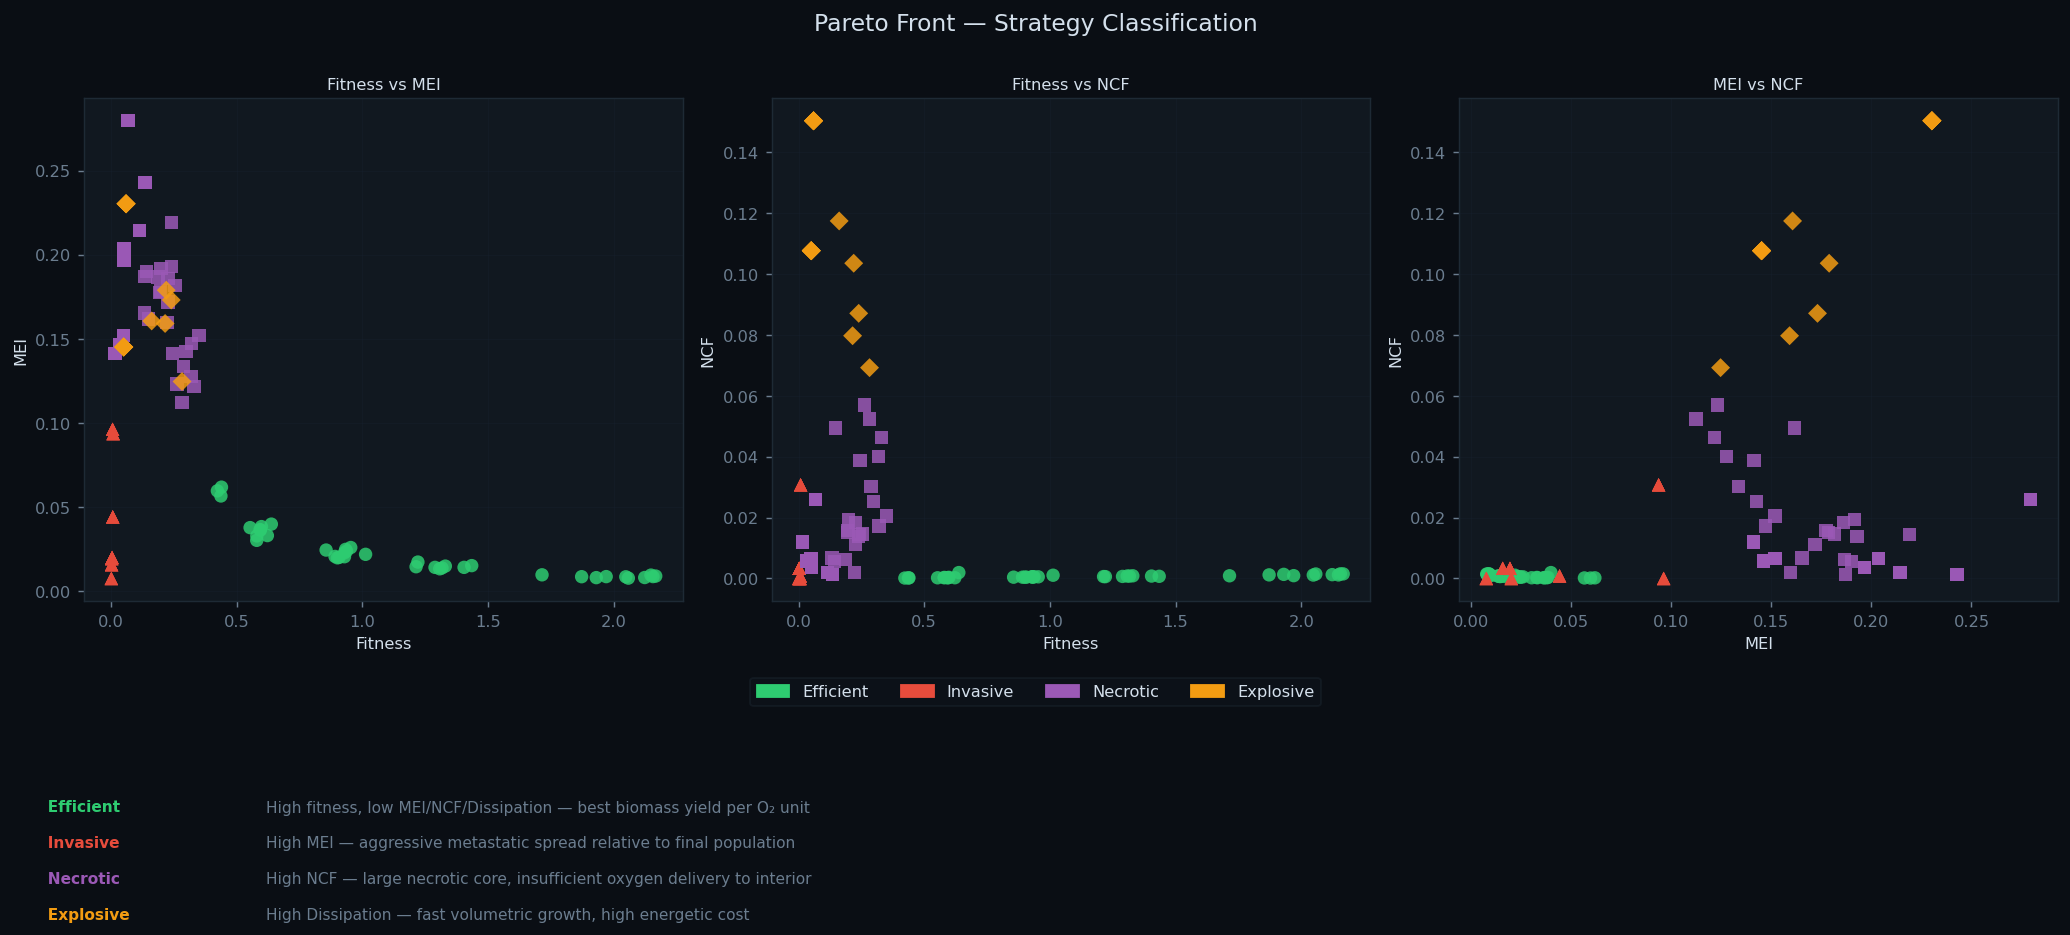

  Saved results\final-data\pareto_results\01_strategy_classification.png


In [50]:
print("  Fig 01 — Strategy classification")
fig01_strategy_classification(front)

  Fig 02 — Pairwise trade-off matrix


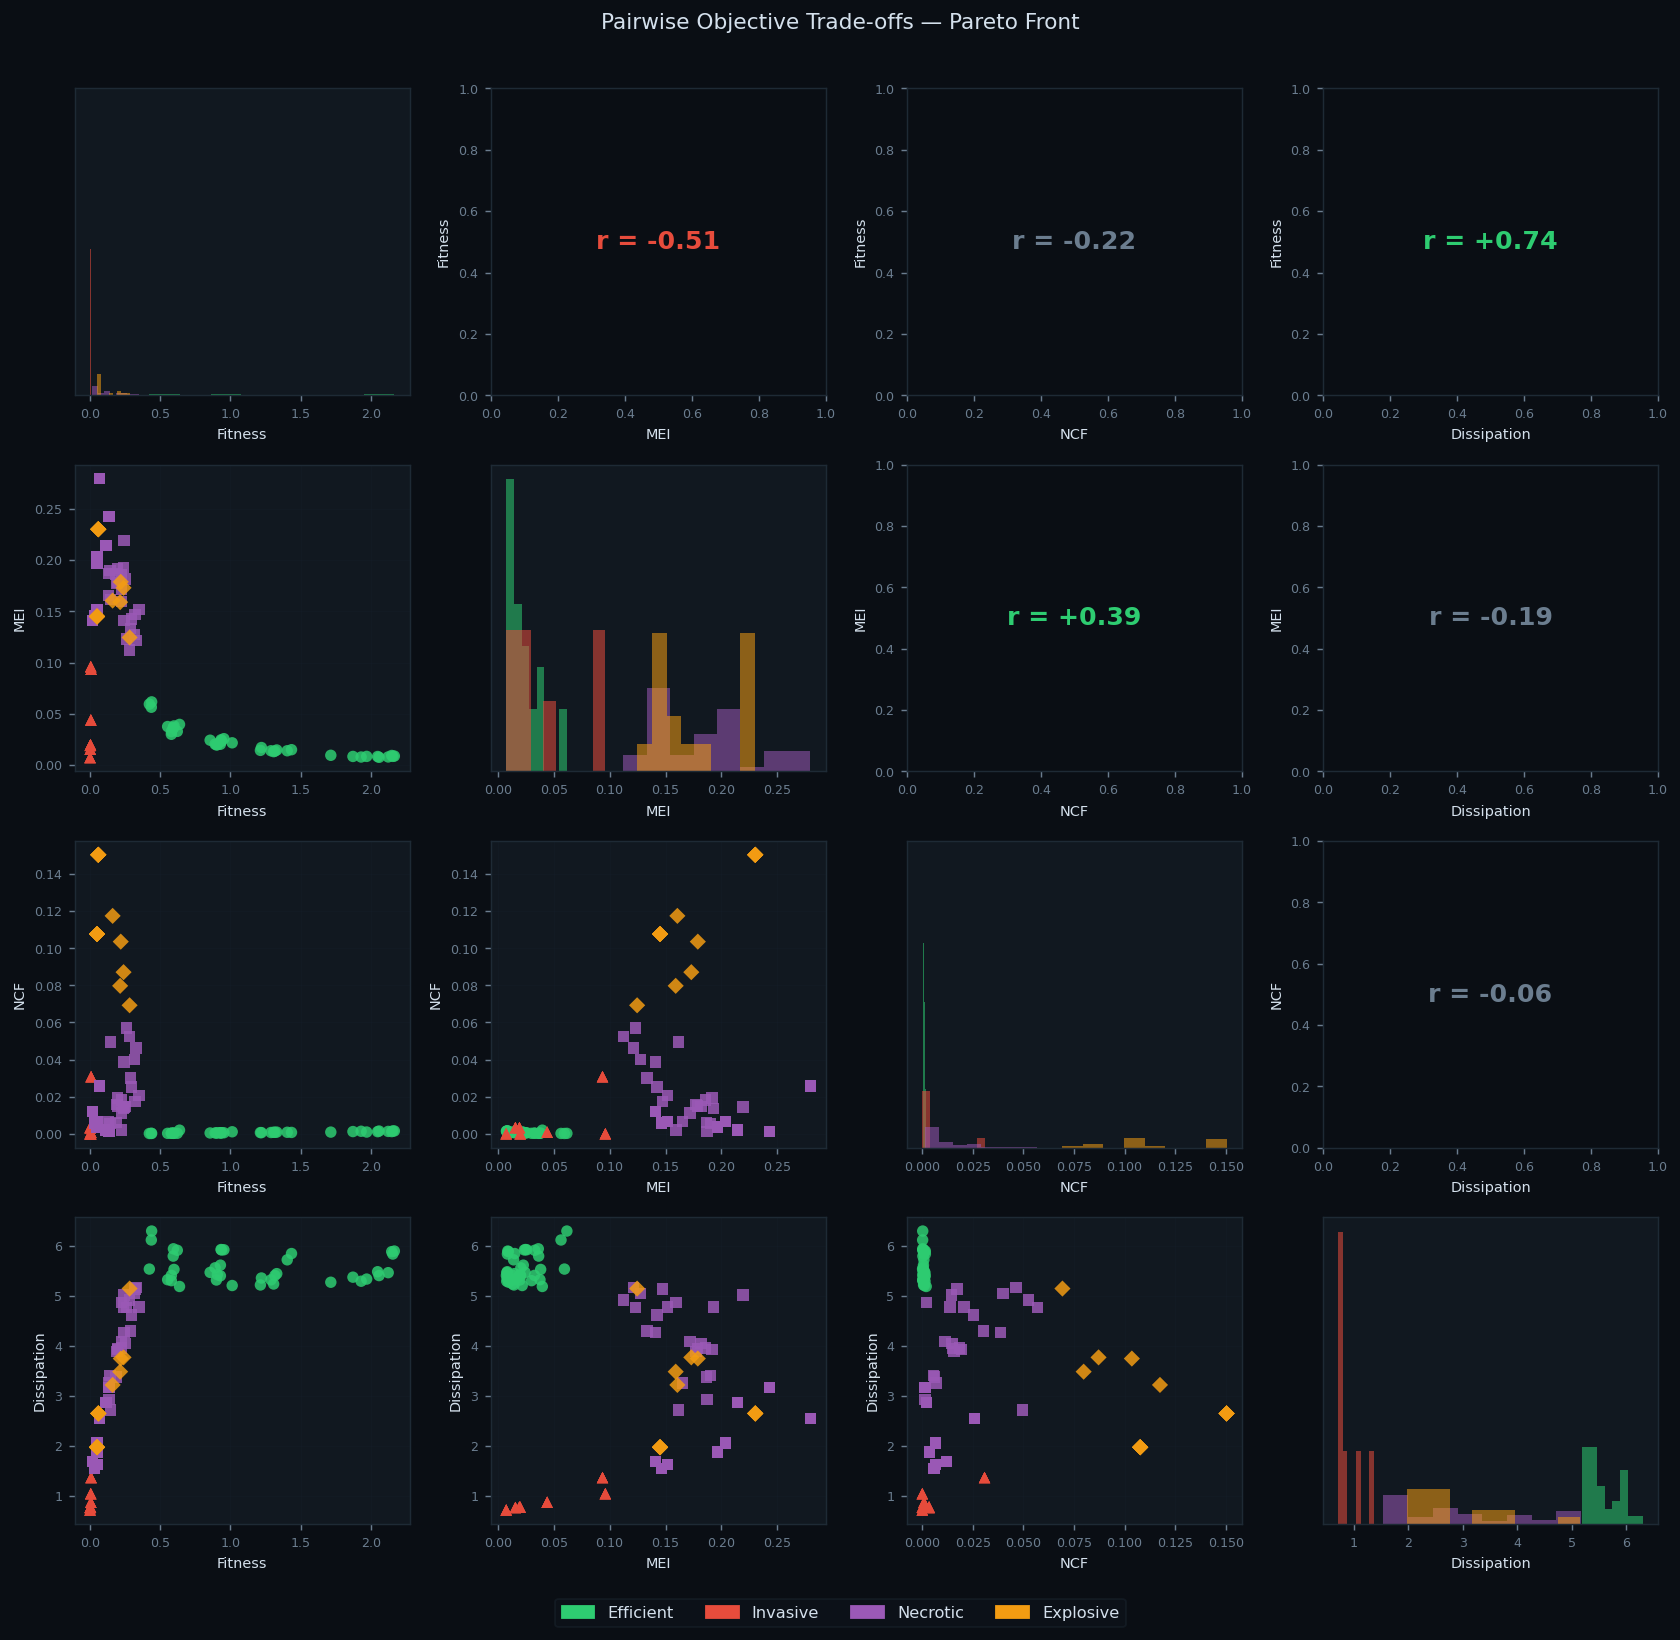

  Saved results\final-data\pareto_results\02_tradeoff_matrix.png


In [51]:
print("  Fig 02 — Pairwise trade-off matrix")
fig02_tradeoff_matrix(front)

  Fig 03 — Phase heatmaps (one file per objective)


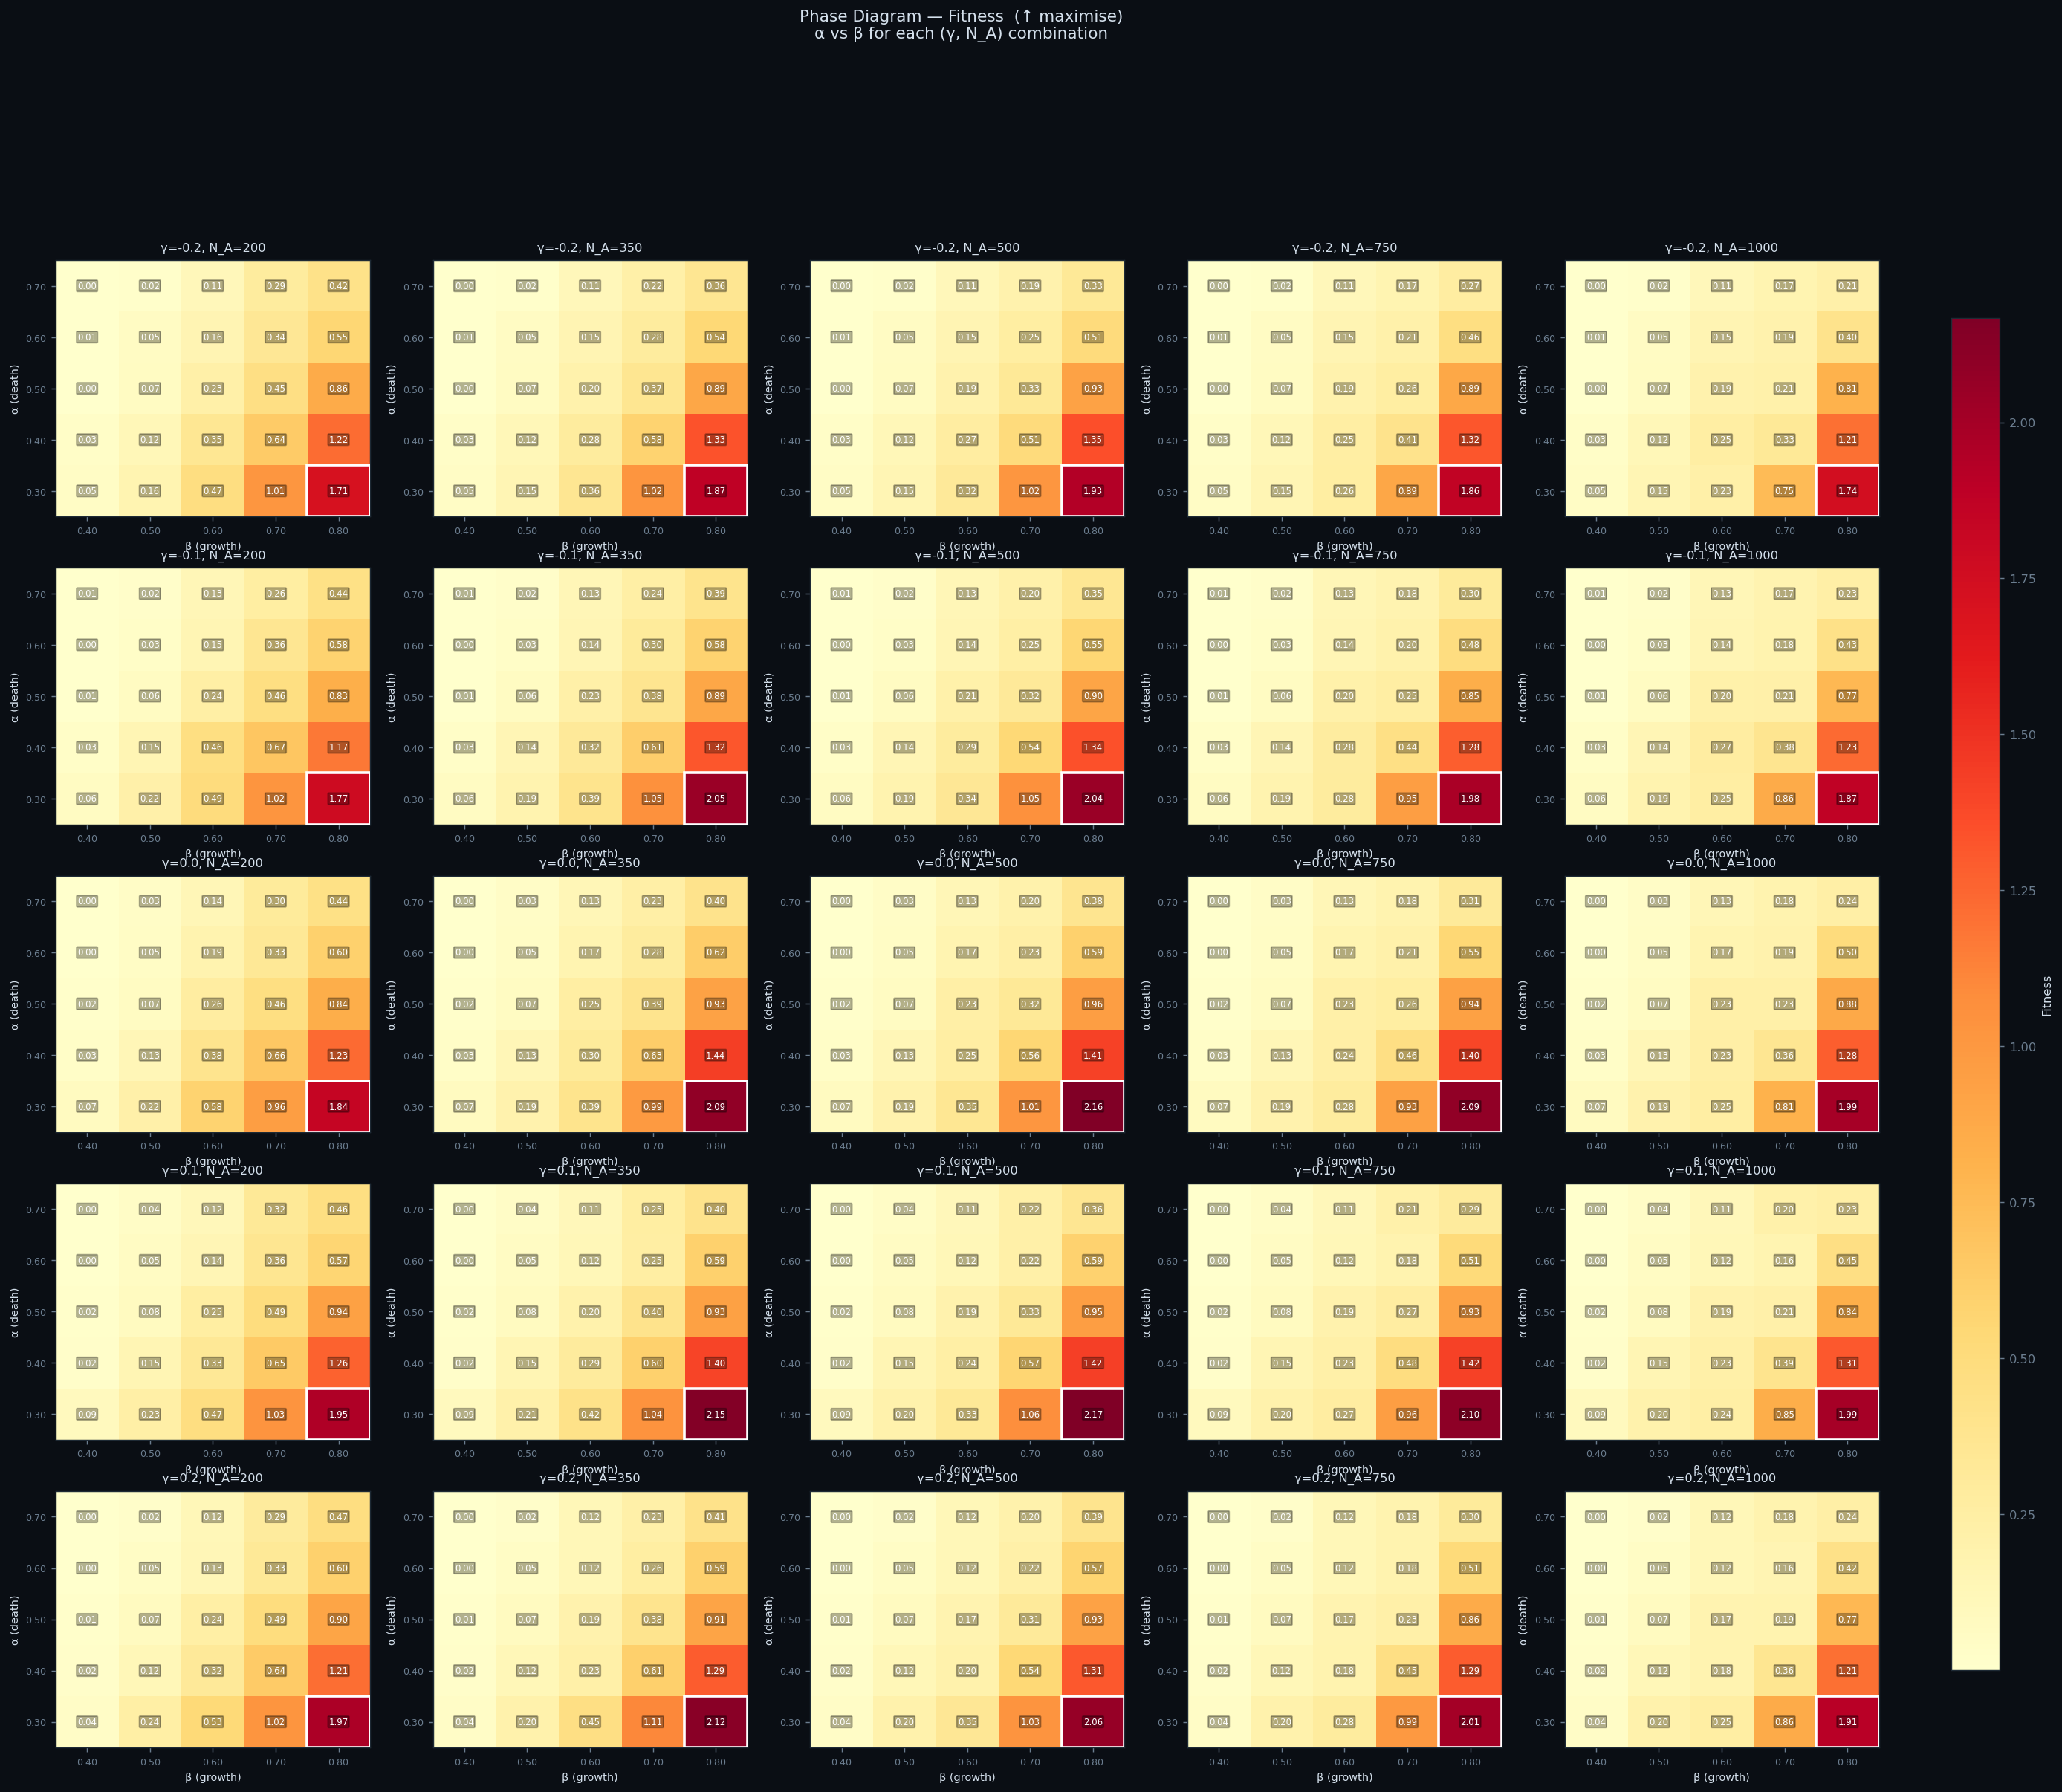

  Saved results\final-data\pareto_results\03_phase_heatmaps_fitness.png


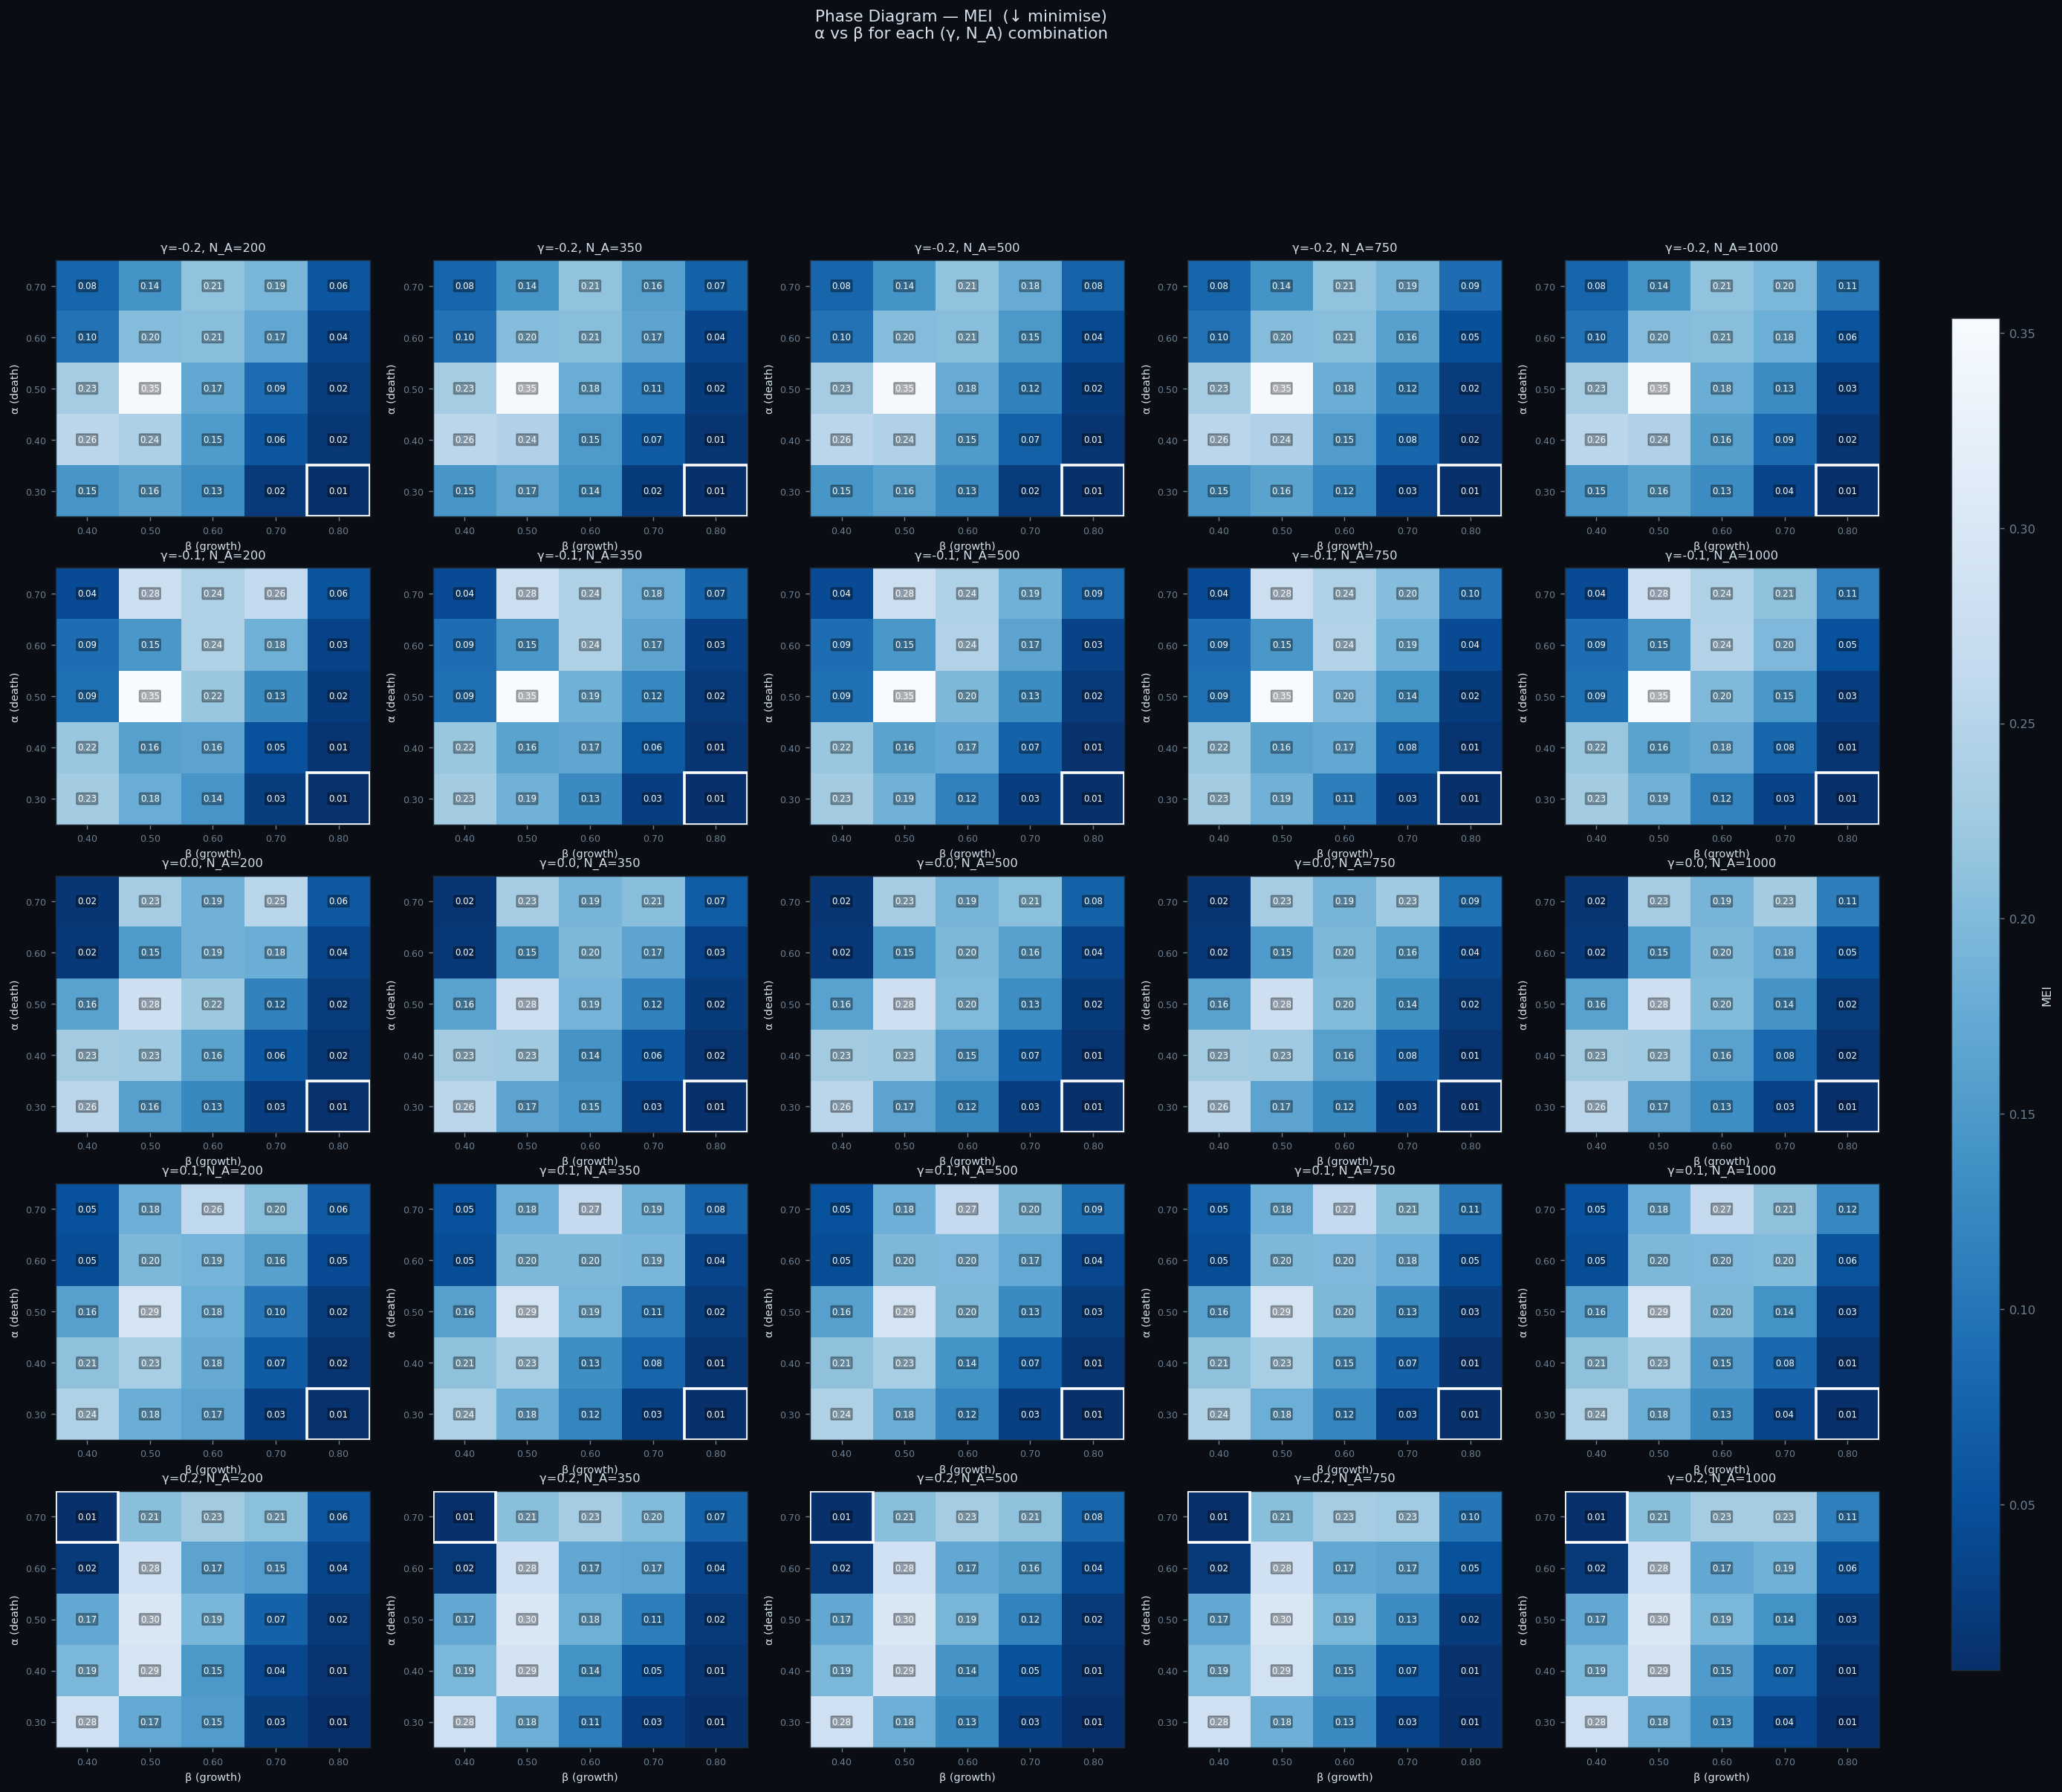

  Saved results\final-data\pareto_results\03_phase_heatmaps_mei.png


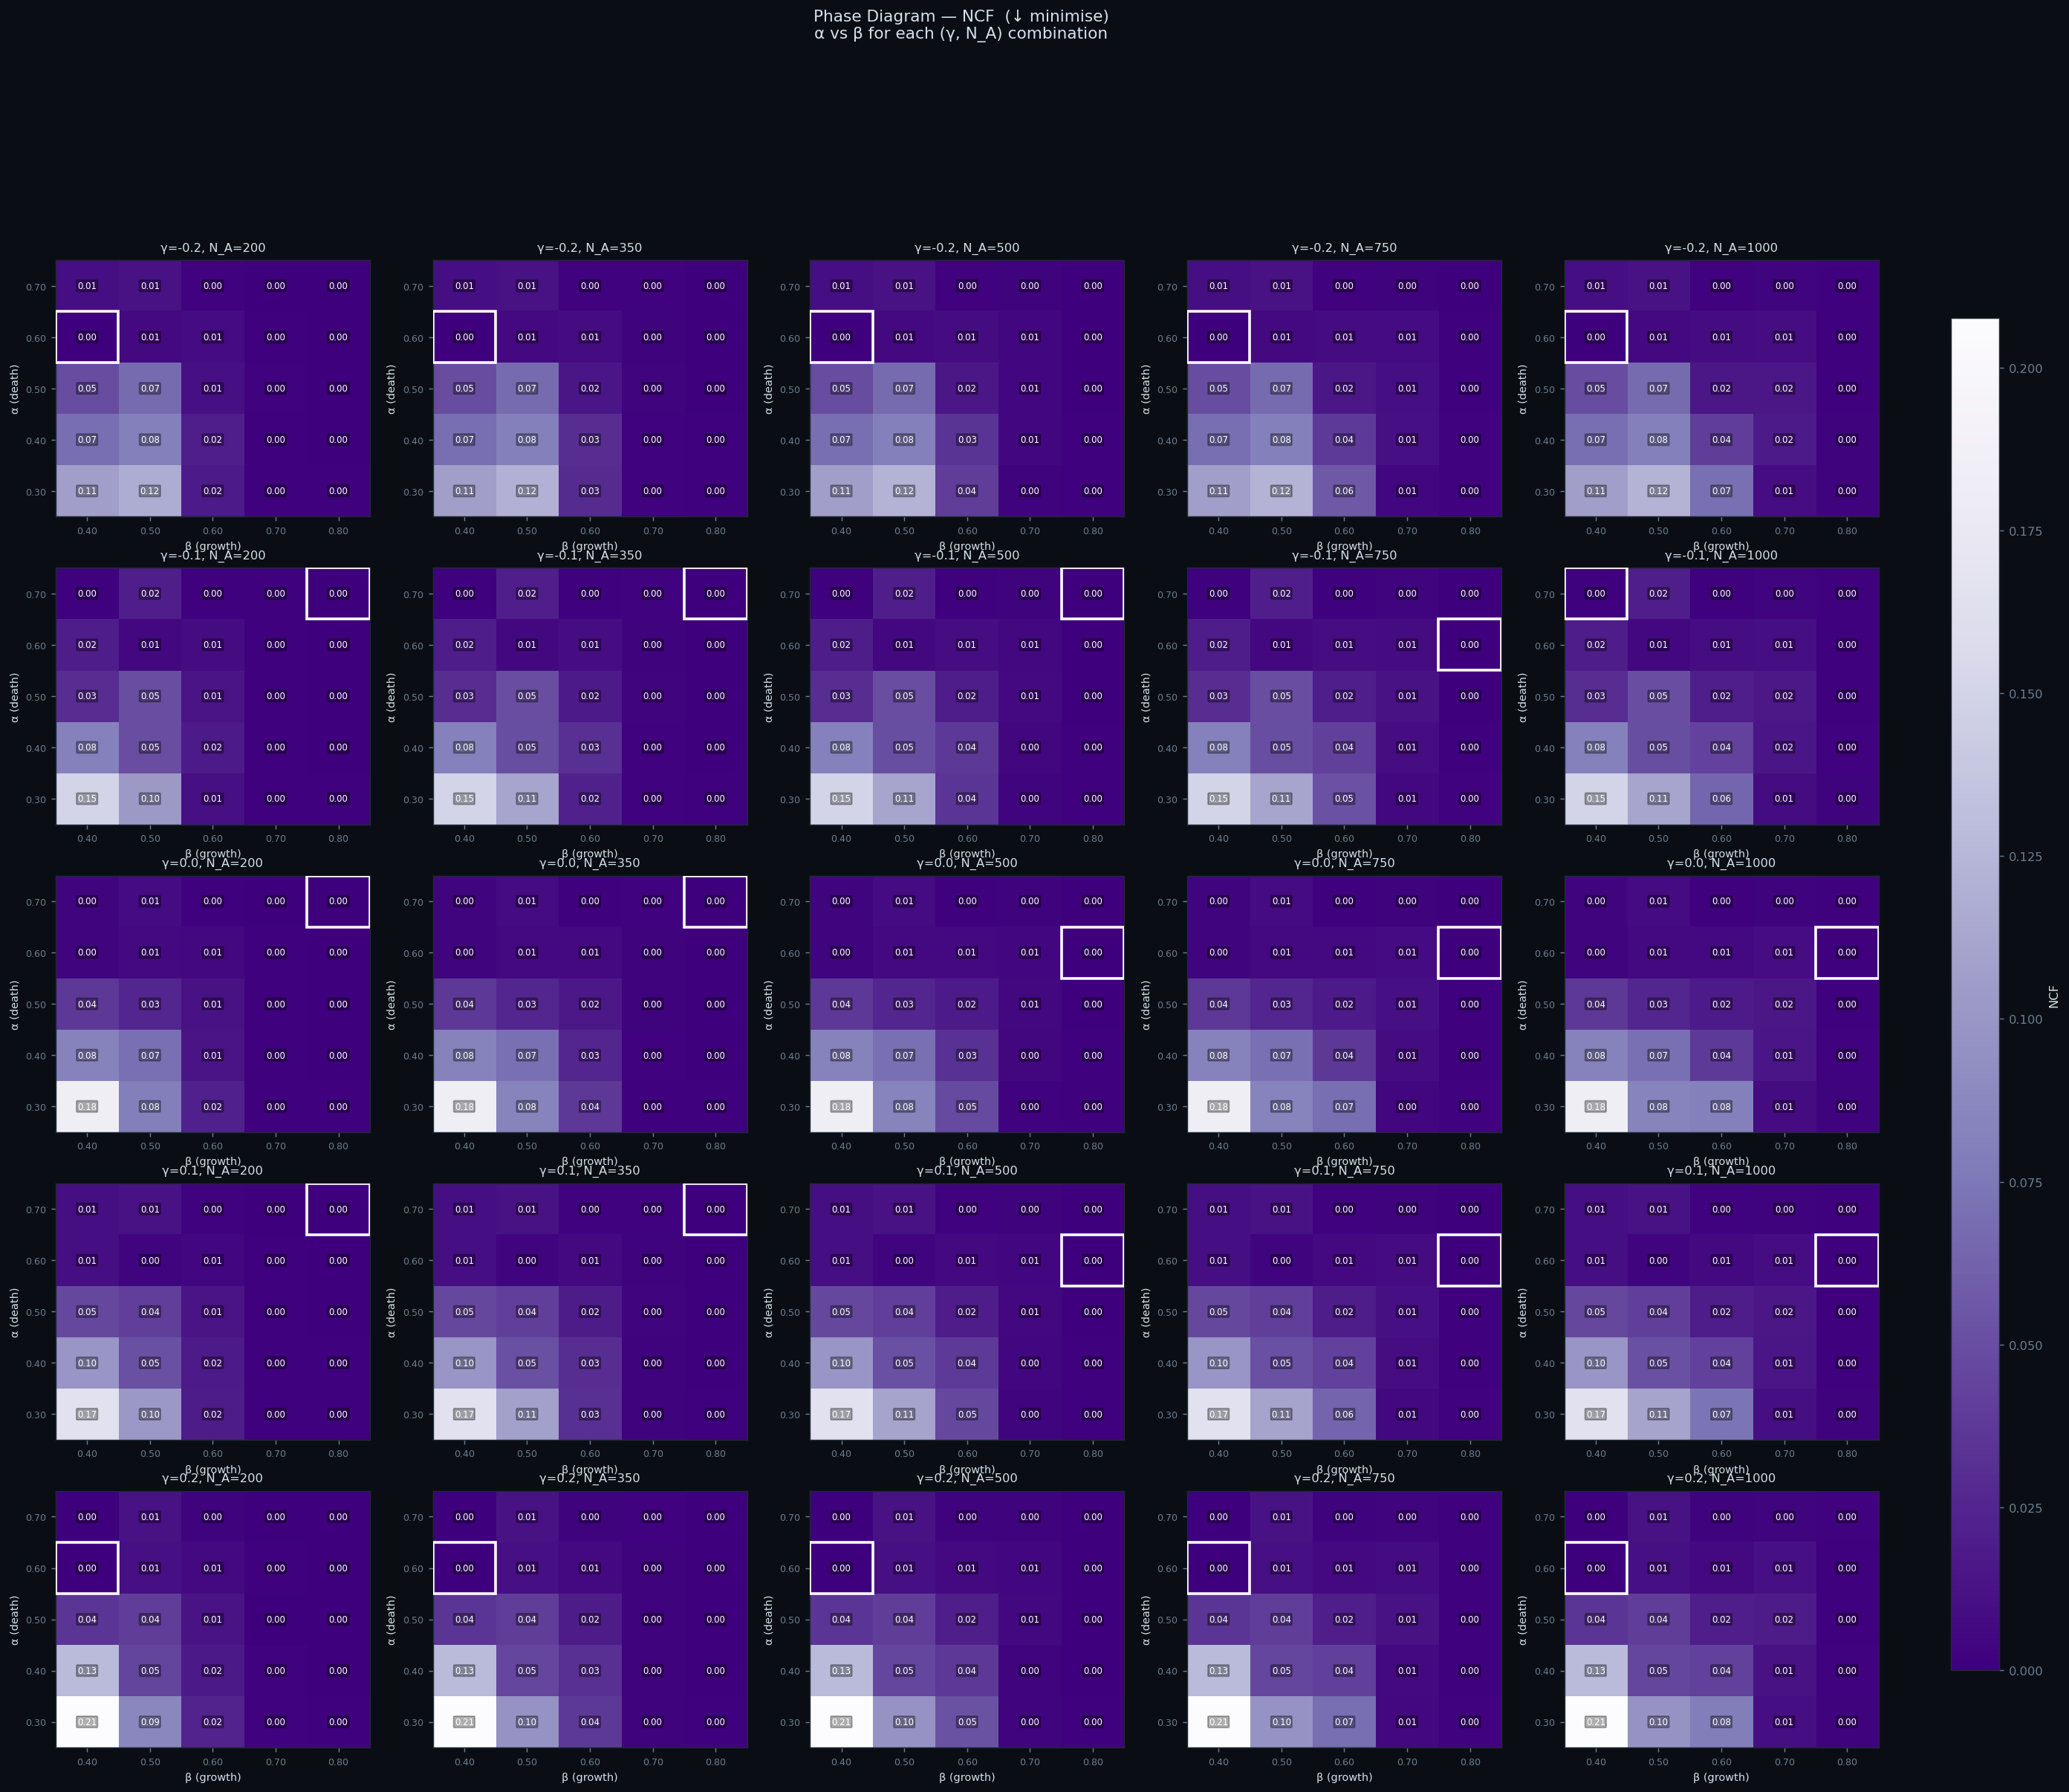

  Saved results\final-data\pareto_results\03_phase_heatmaps_ncf.png


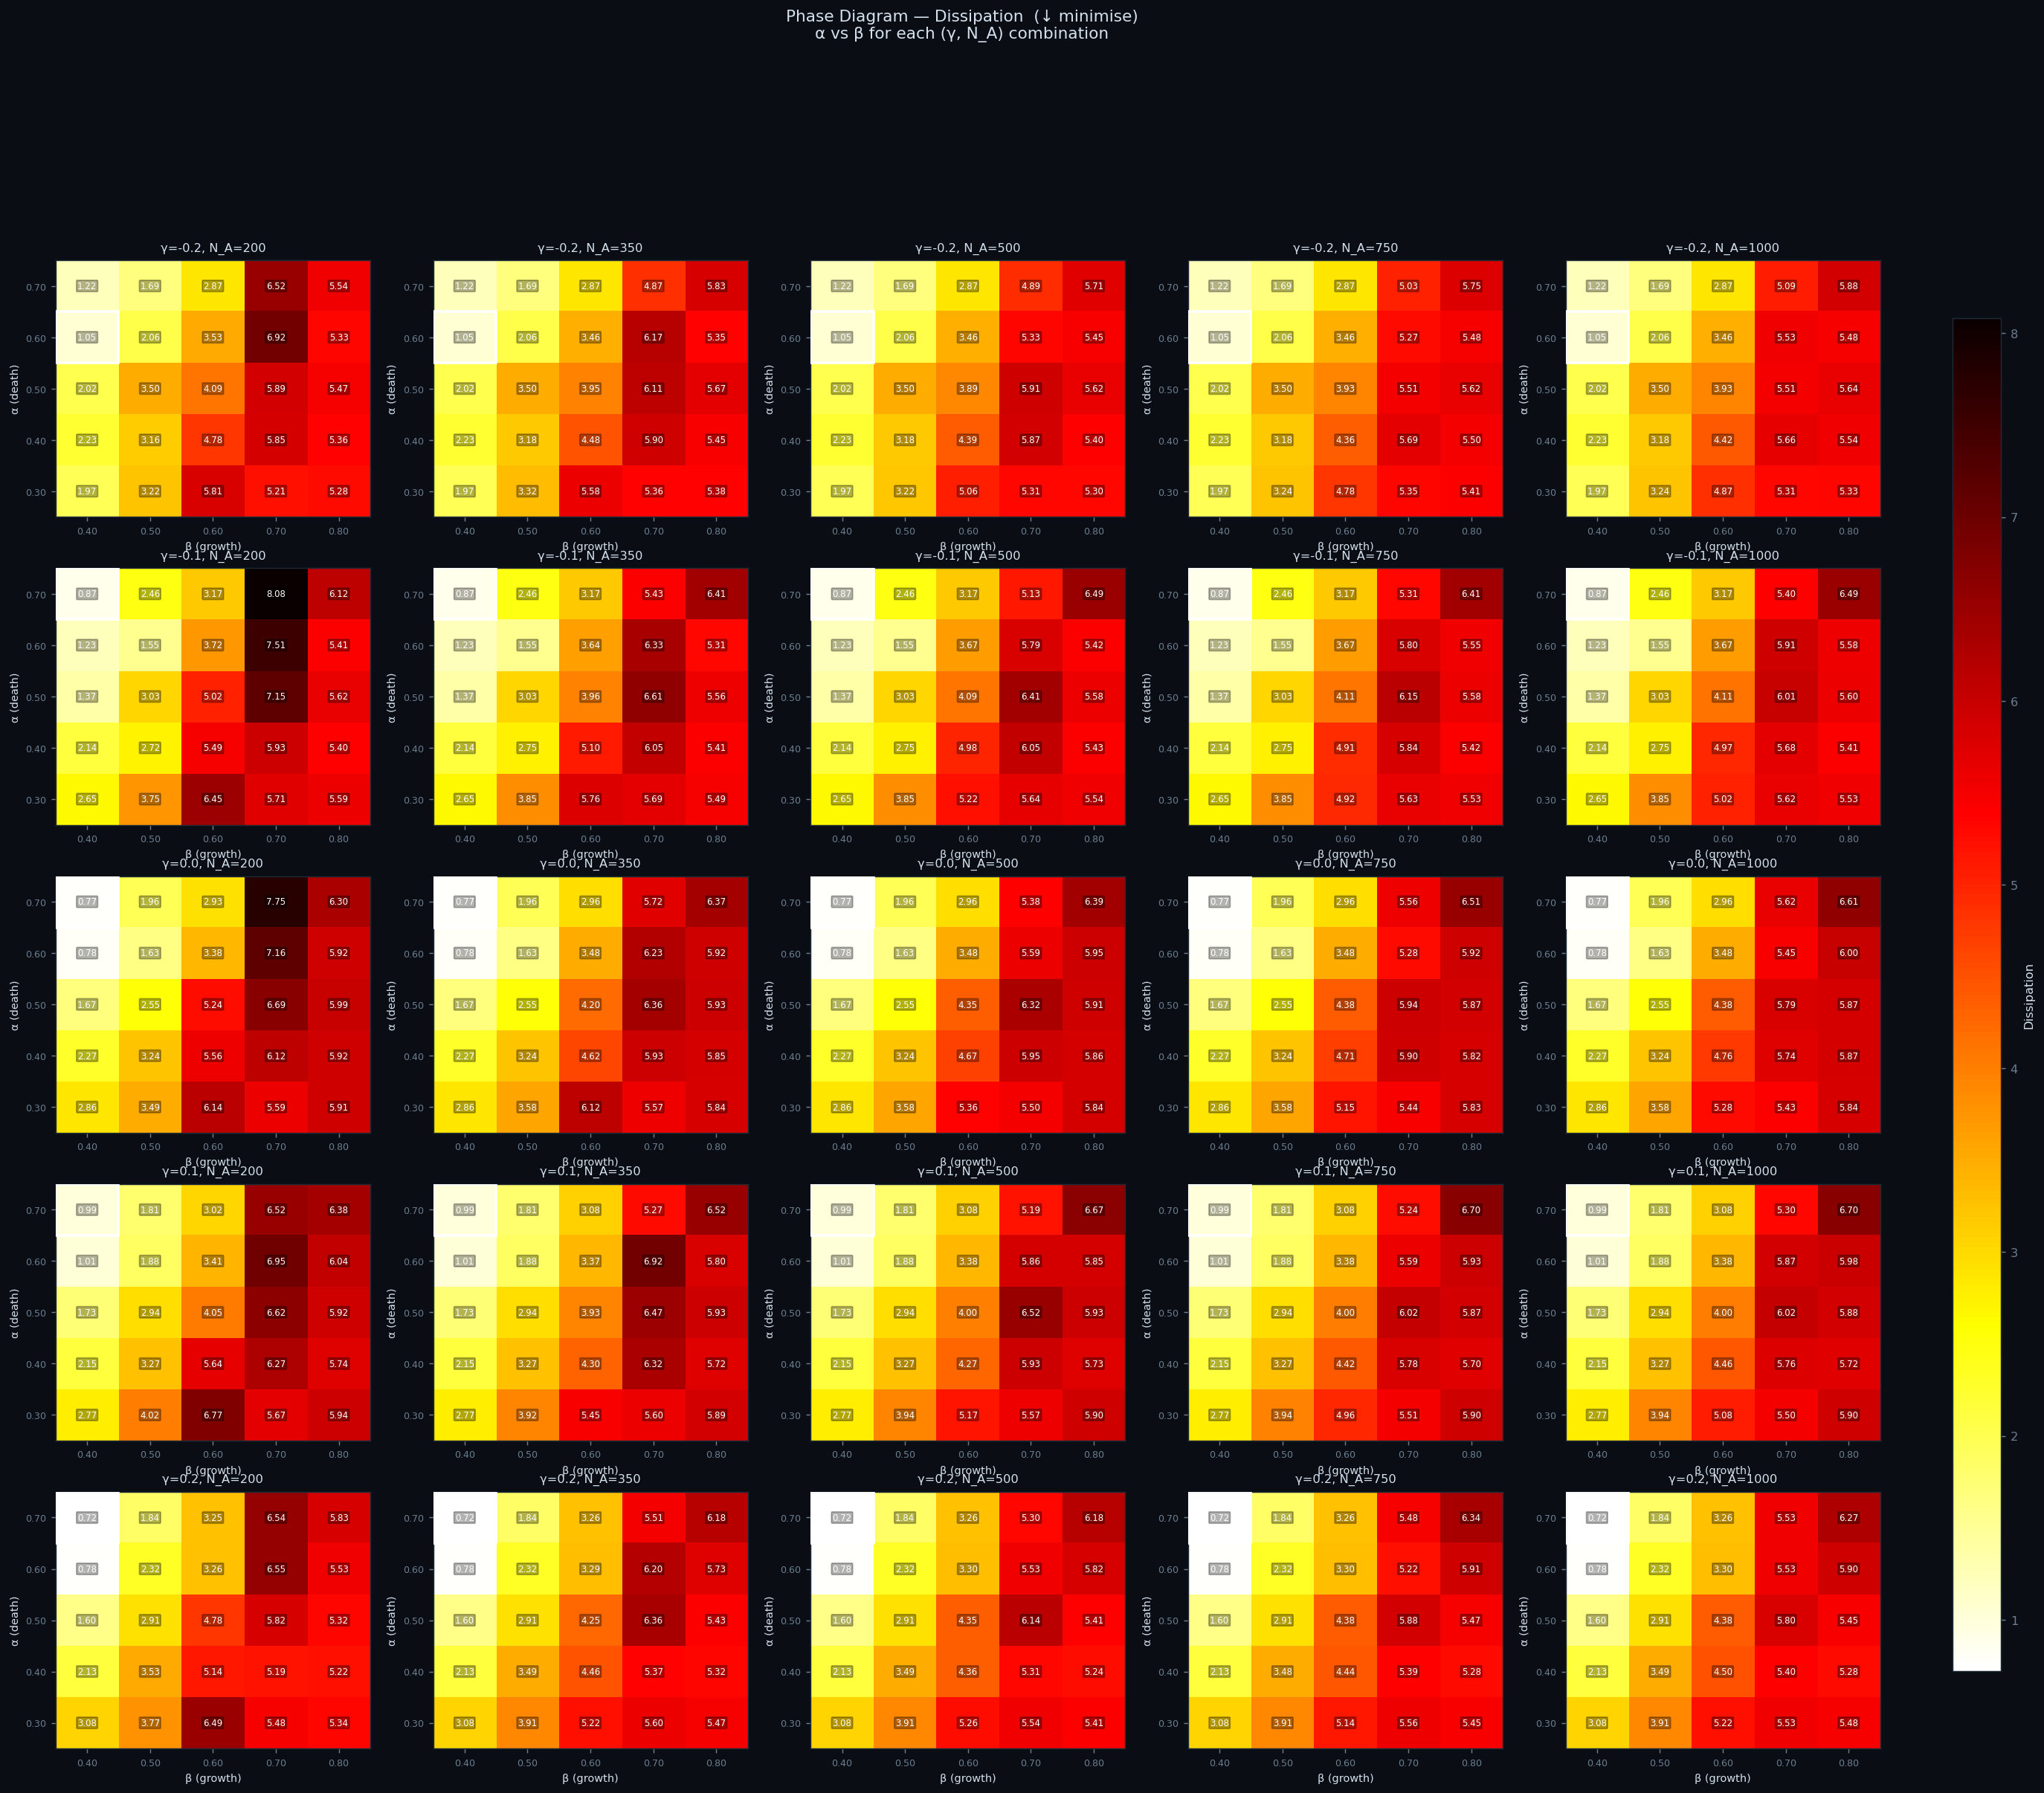

  Saved results\final-data\pareto_results\03_phase_heatmaps_dissipation.png


In [52]:
print("  Fig 03 — Phase heatmaps (one file per objective)")
fig03_phase_heatmaps(pf)

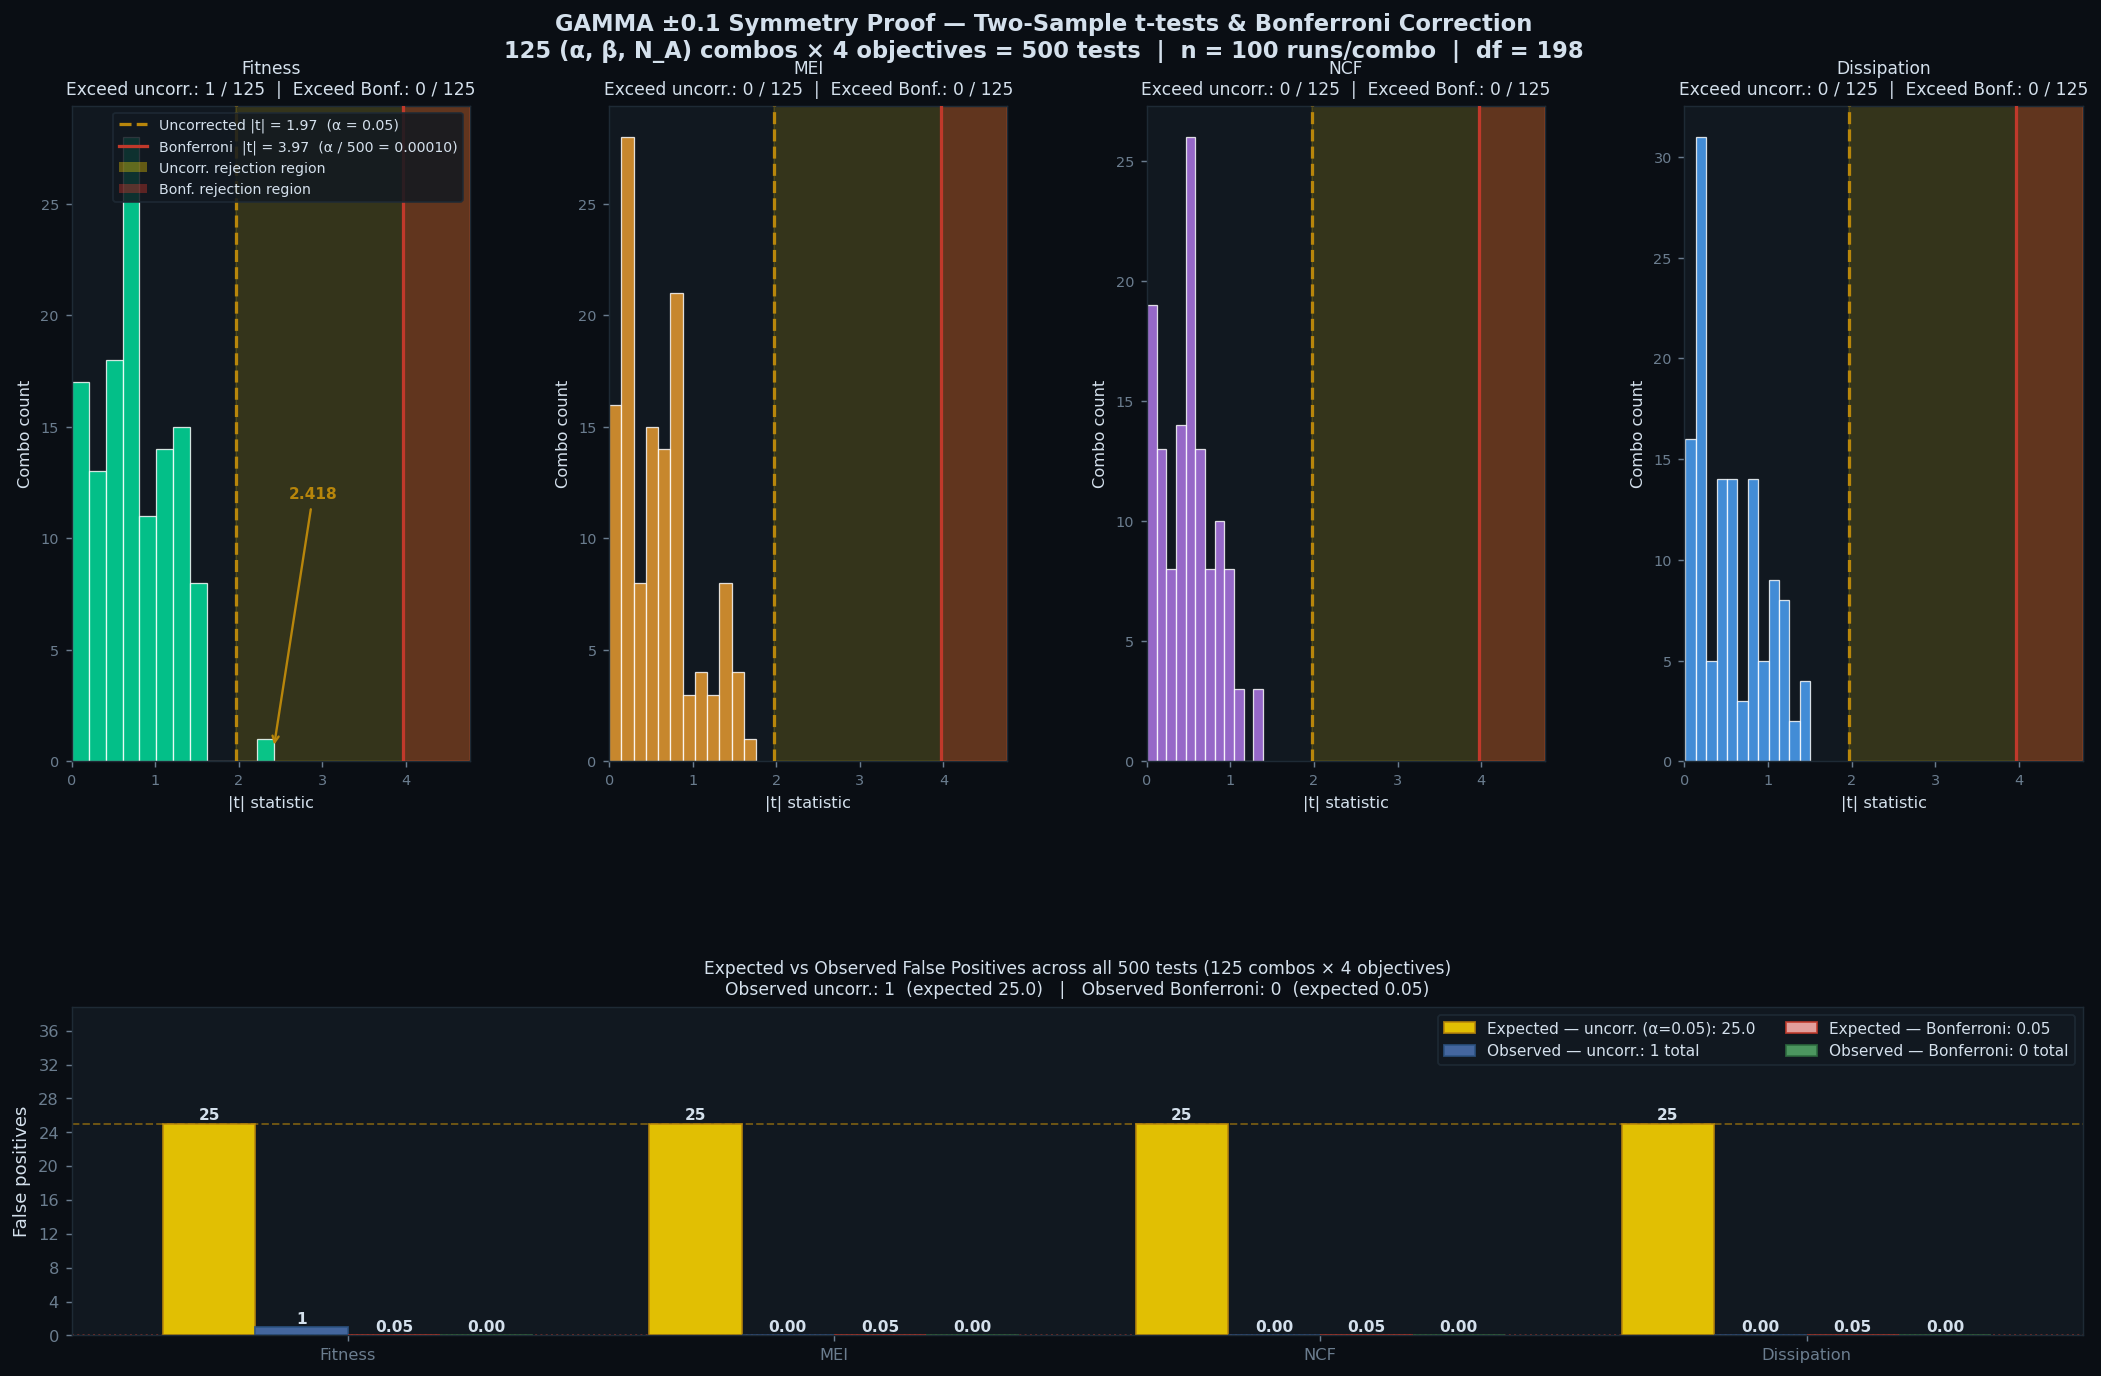

  Saved results\final-data\pareto_results\gamma_t_symmetry.png

            SYMMETRY PROOF SUMMARY  (GAMMA = −0.1 vs +0.1)            
  Total tests          : 125 combos × 4 objectives = 500
  Degrees of freedom   : 198
  Uncorrected |t| crit : 1.9720  (per-test α = 0.05)
  Bonferroni  |t| crit : 3.9713  (α / 500 = 0.000100)
----------------------------------------------------------------------
  Objective       Max |t|    Exceed uncorr.   Exceed Bonf.
----------------------------------------------------------------------
  Fitness          2.4179        1 / 125           0 / 125
                  → worst combo: α=0.4, β=0.6, N_A=200.0
  MEI              1.7588        0 / 125           0 / 125
                  → worst combo: α=0.4, β=0.6, N_A=350.0
  NCF              1.3882        0 / 125           0 / 125
                  → worst combo: α=0.5, β=0.8, N_A=500.0
  Dissipation      1.5053        0 / 125           0 / 125
                  → worst combo: α=0.7, β=0.7, N_A=200.0
-------

In [53]:
fig_additional_gamma()

  Fig 04 — Per-objective analyses
    04_fitness.png …


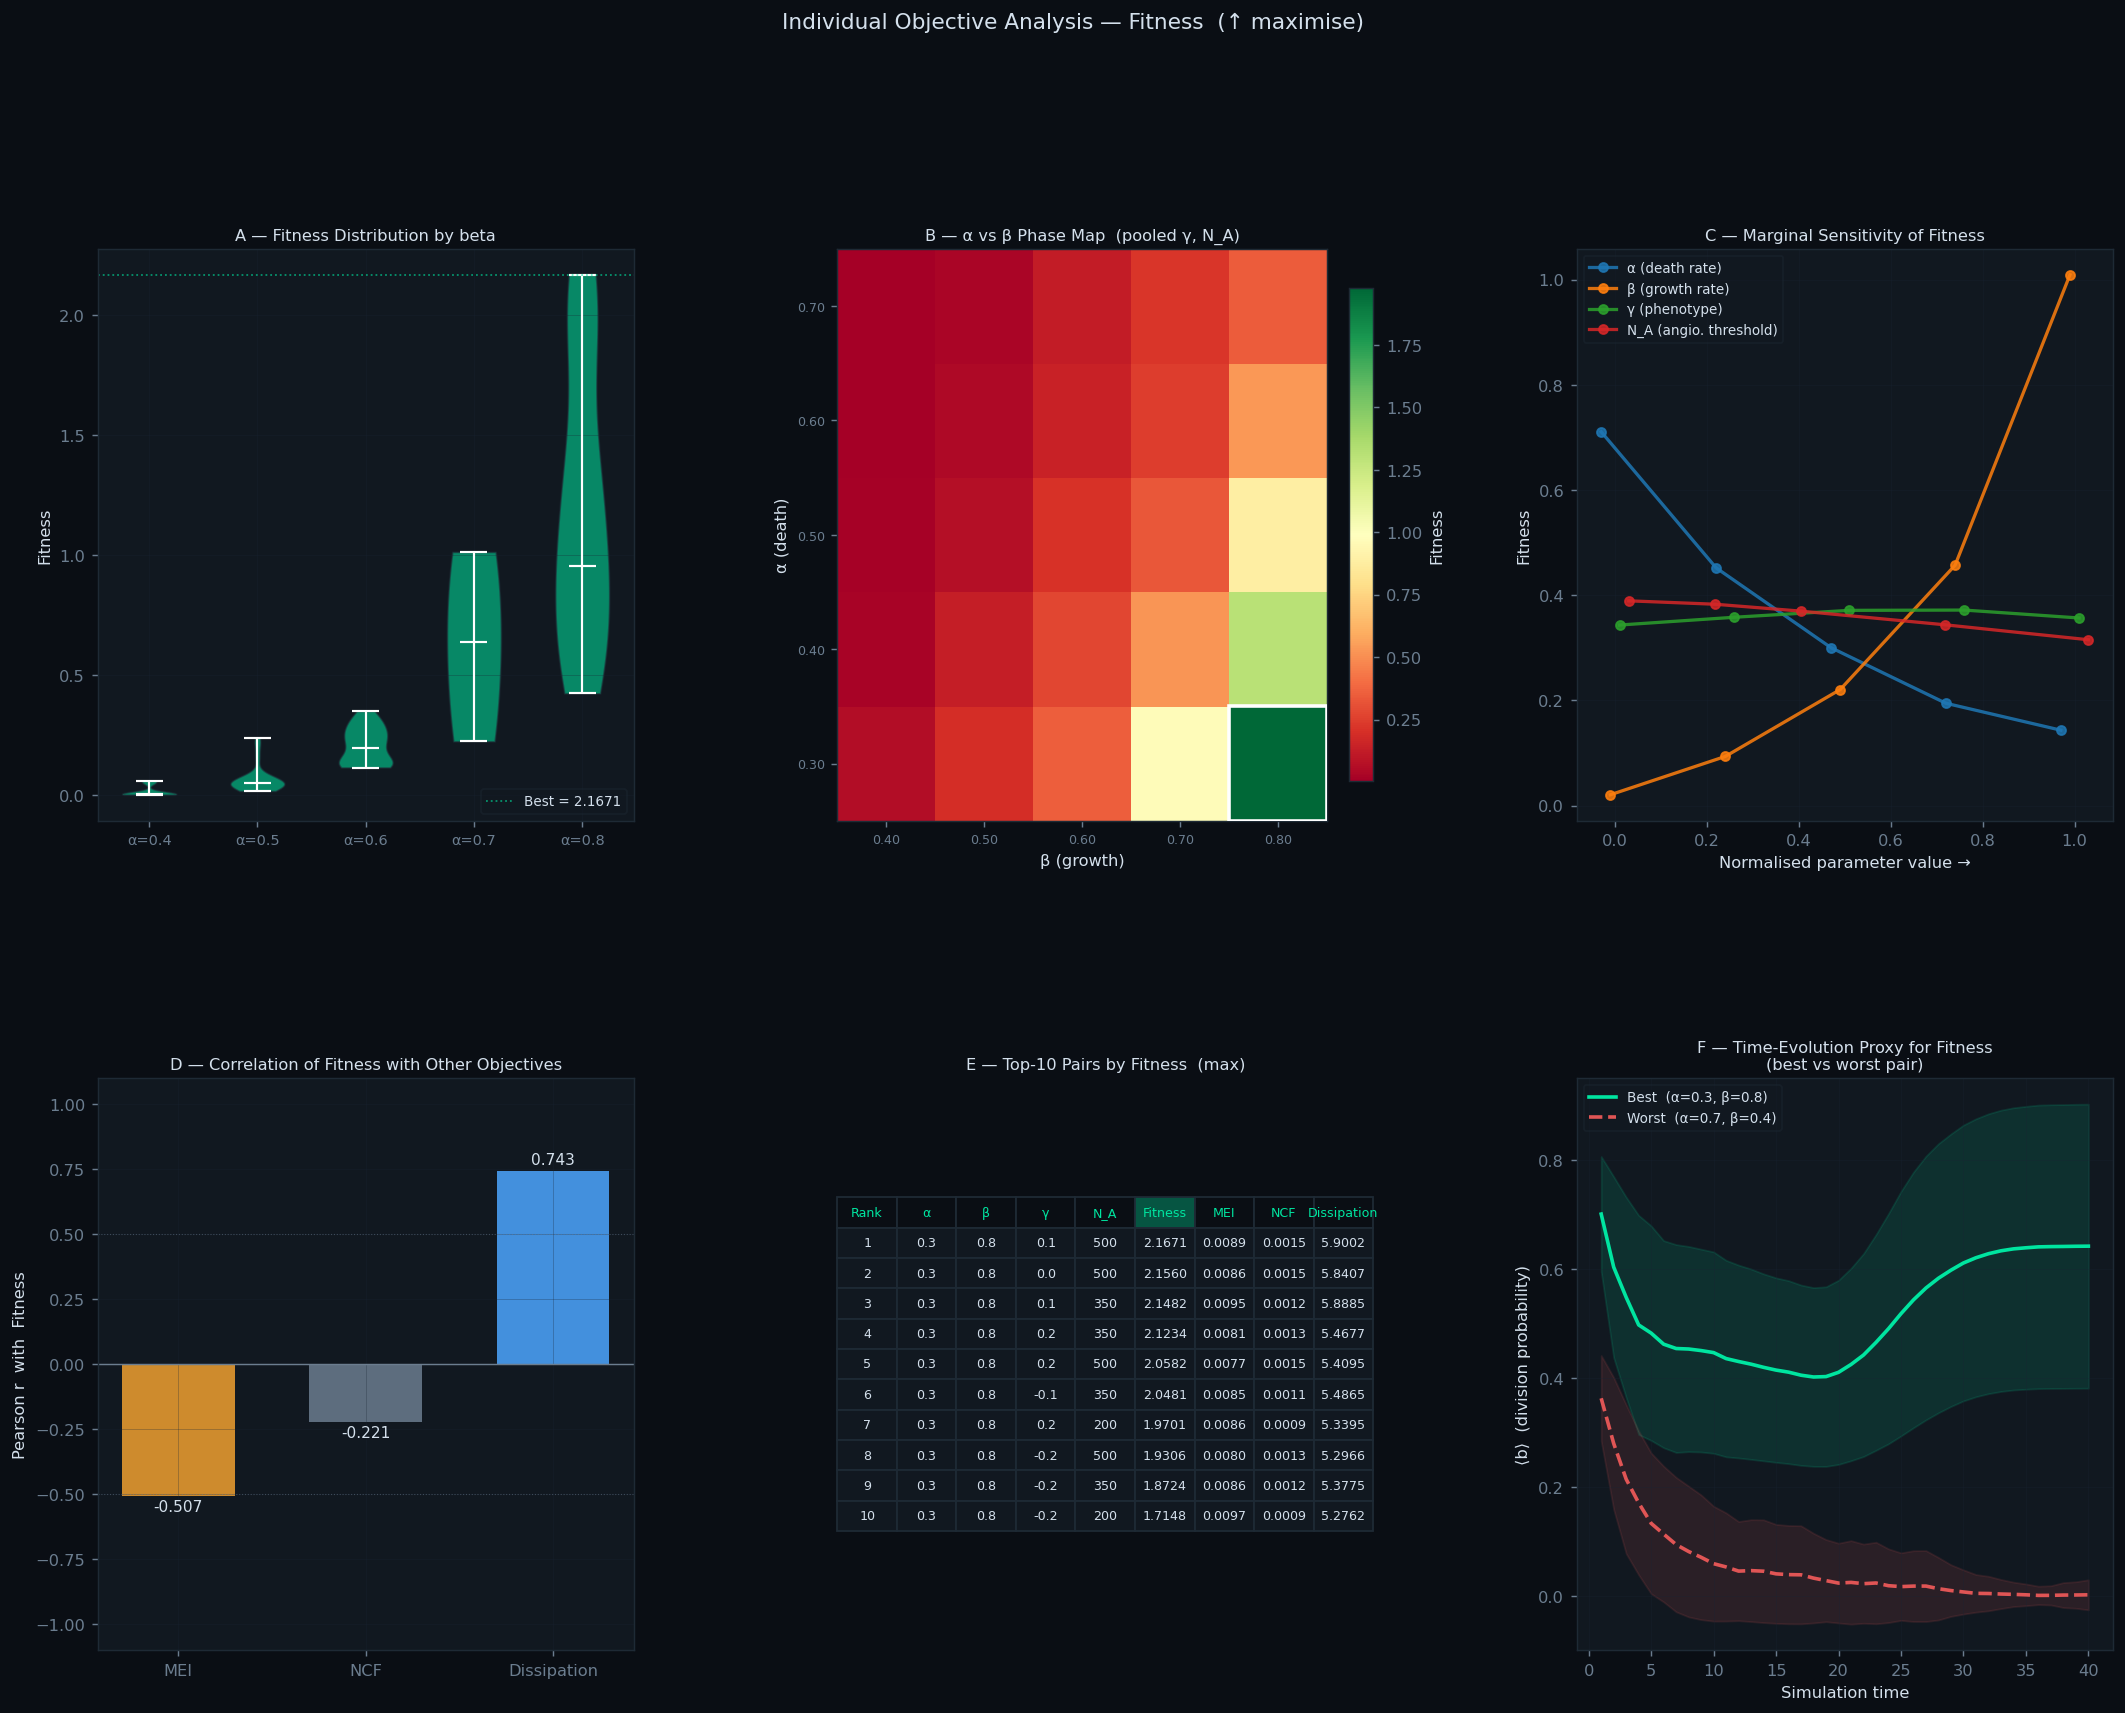

  Saved results\final-data\pareto_results\04_fitness.png
    04_mei.png …


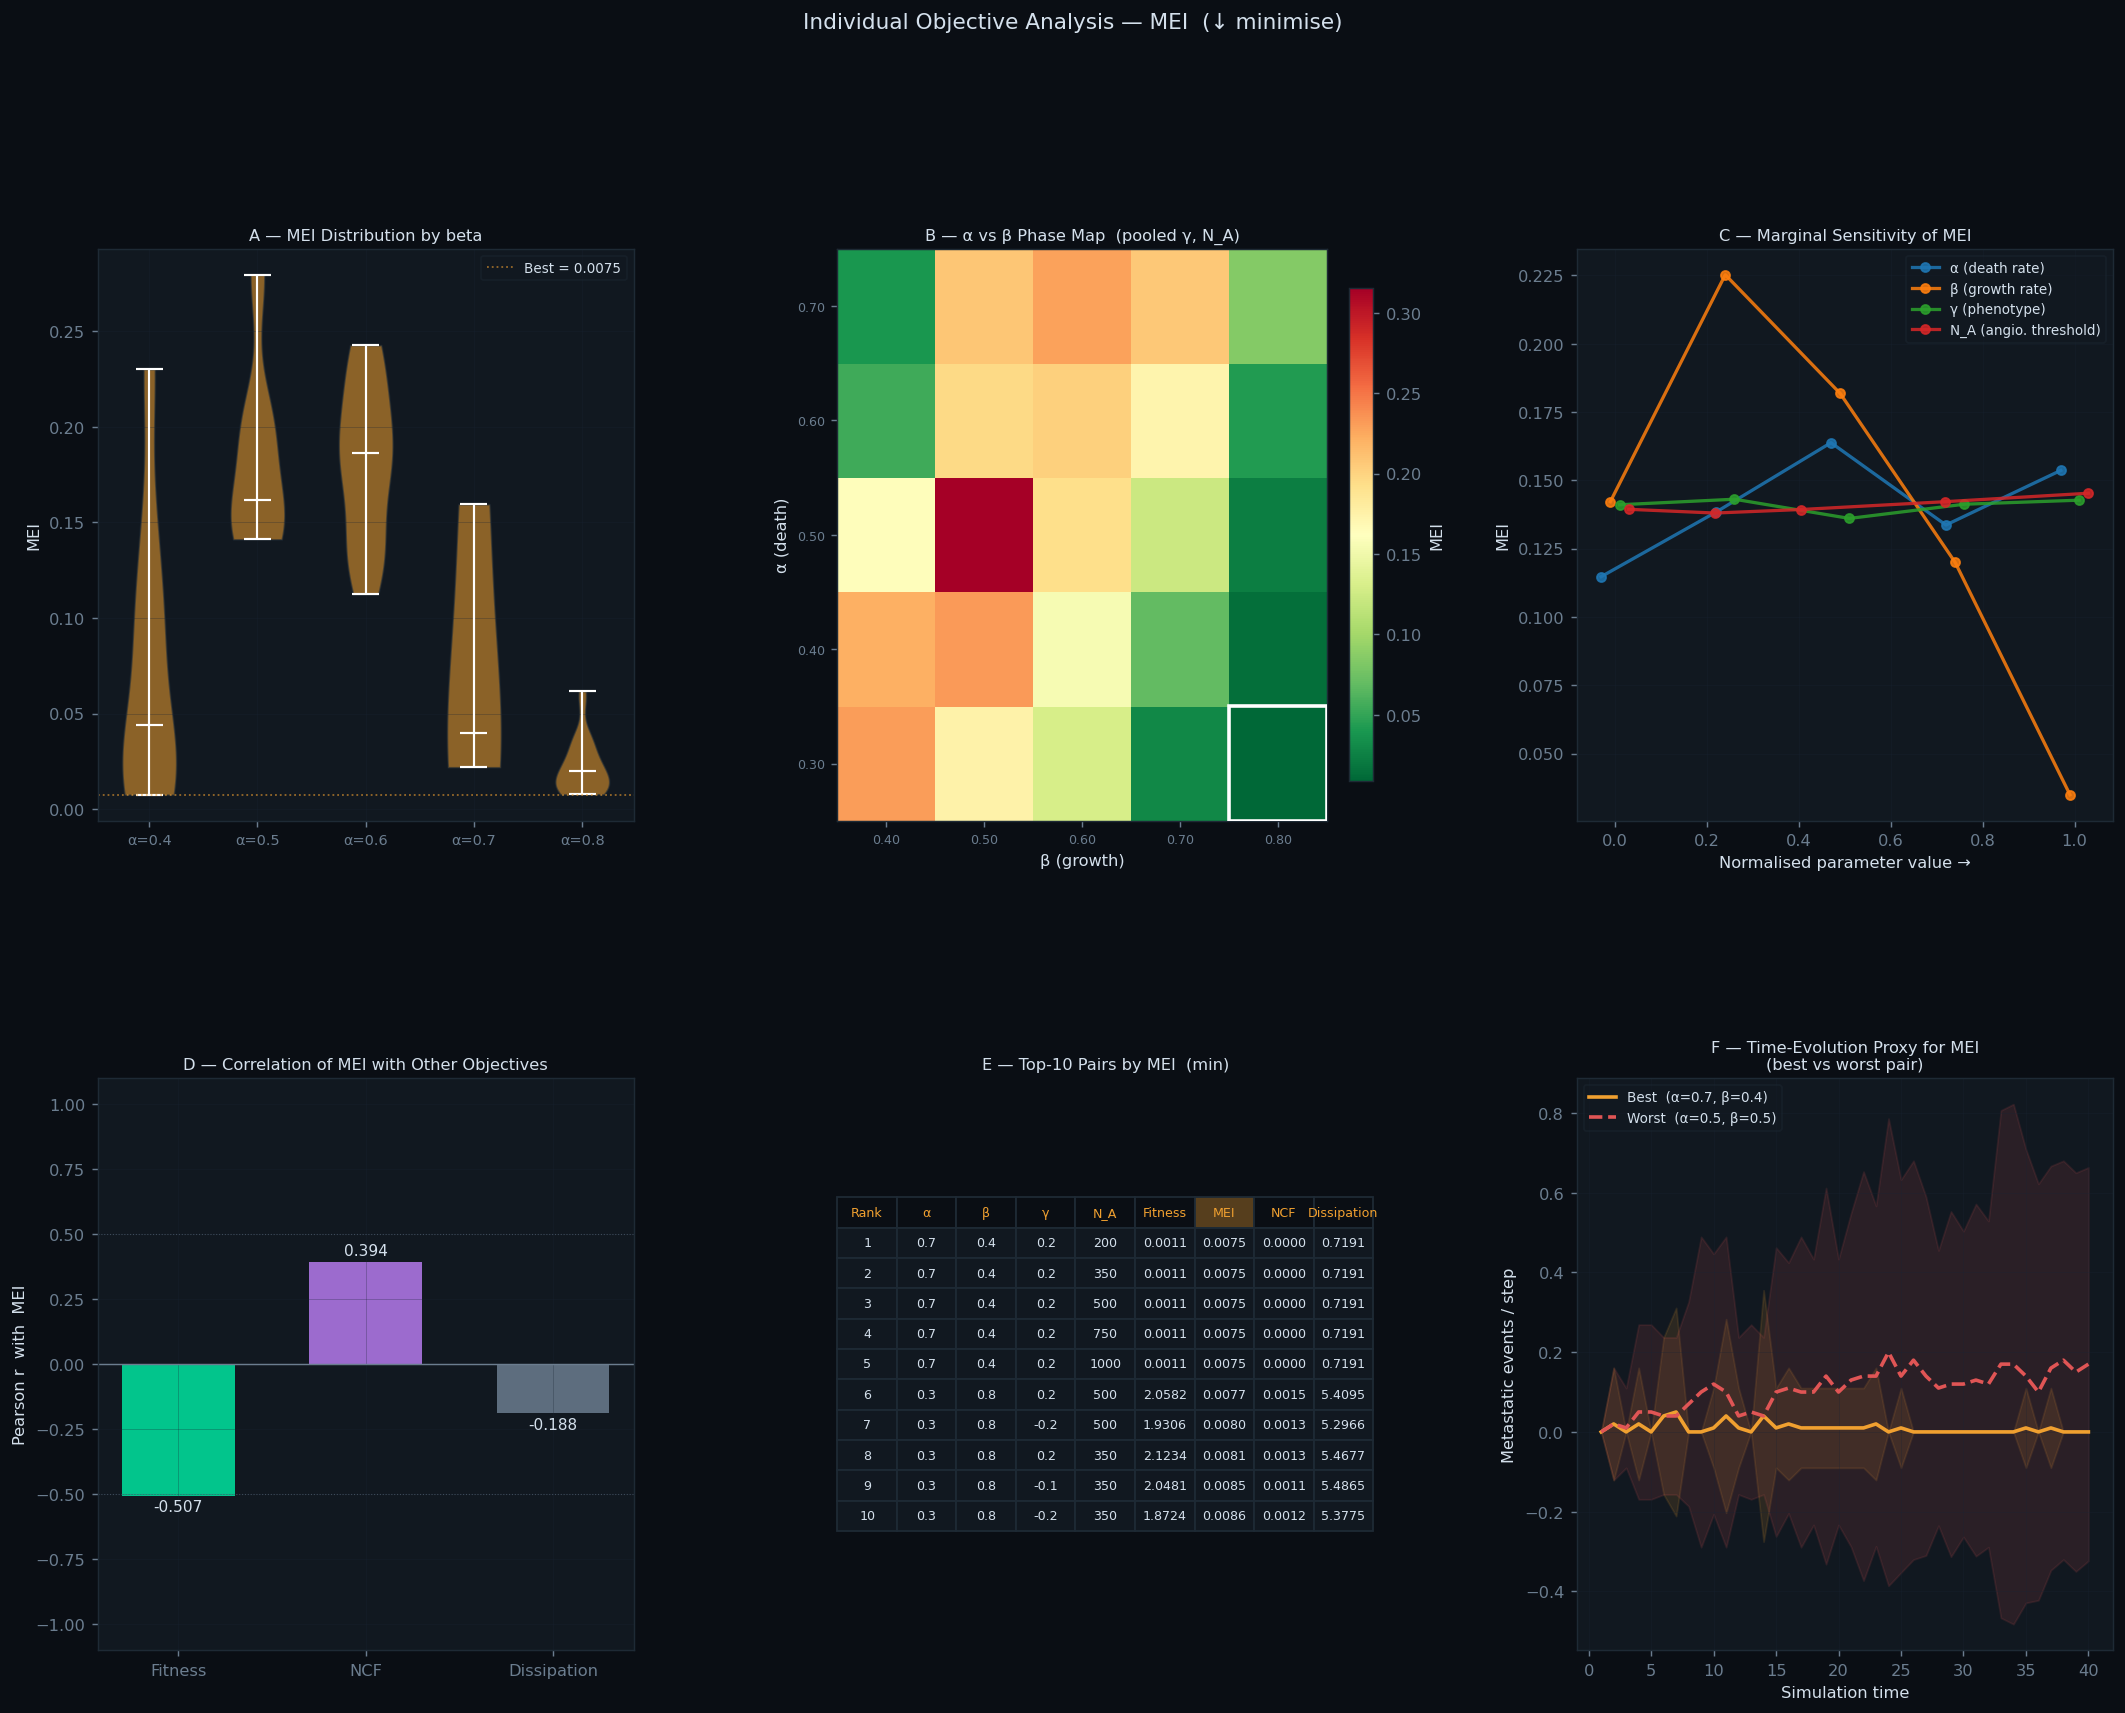

  Saved results\final-data\pareto_results\04_mei.png
    04_ncf.png …


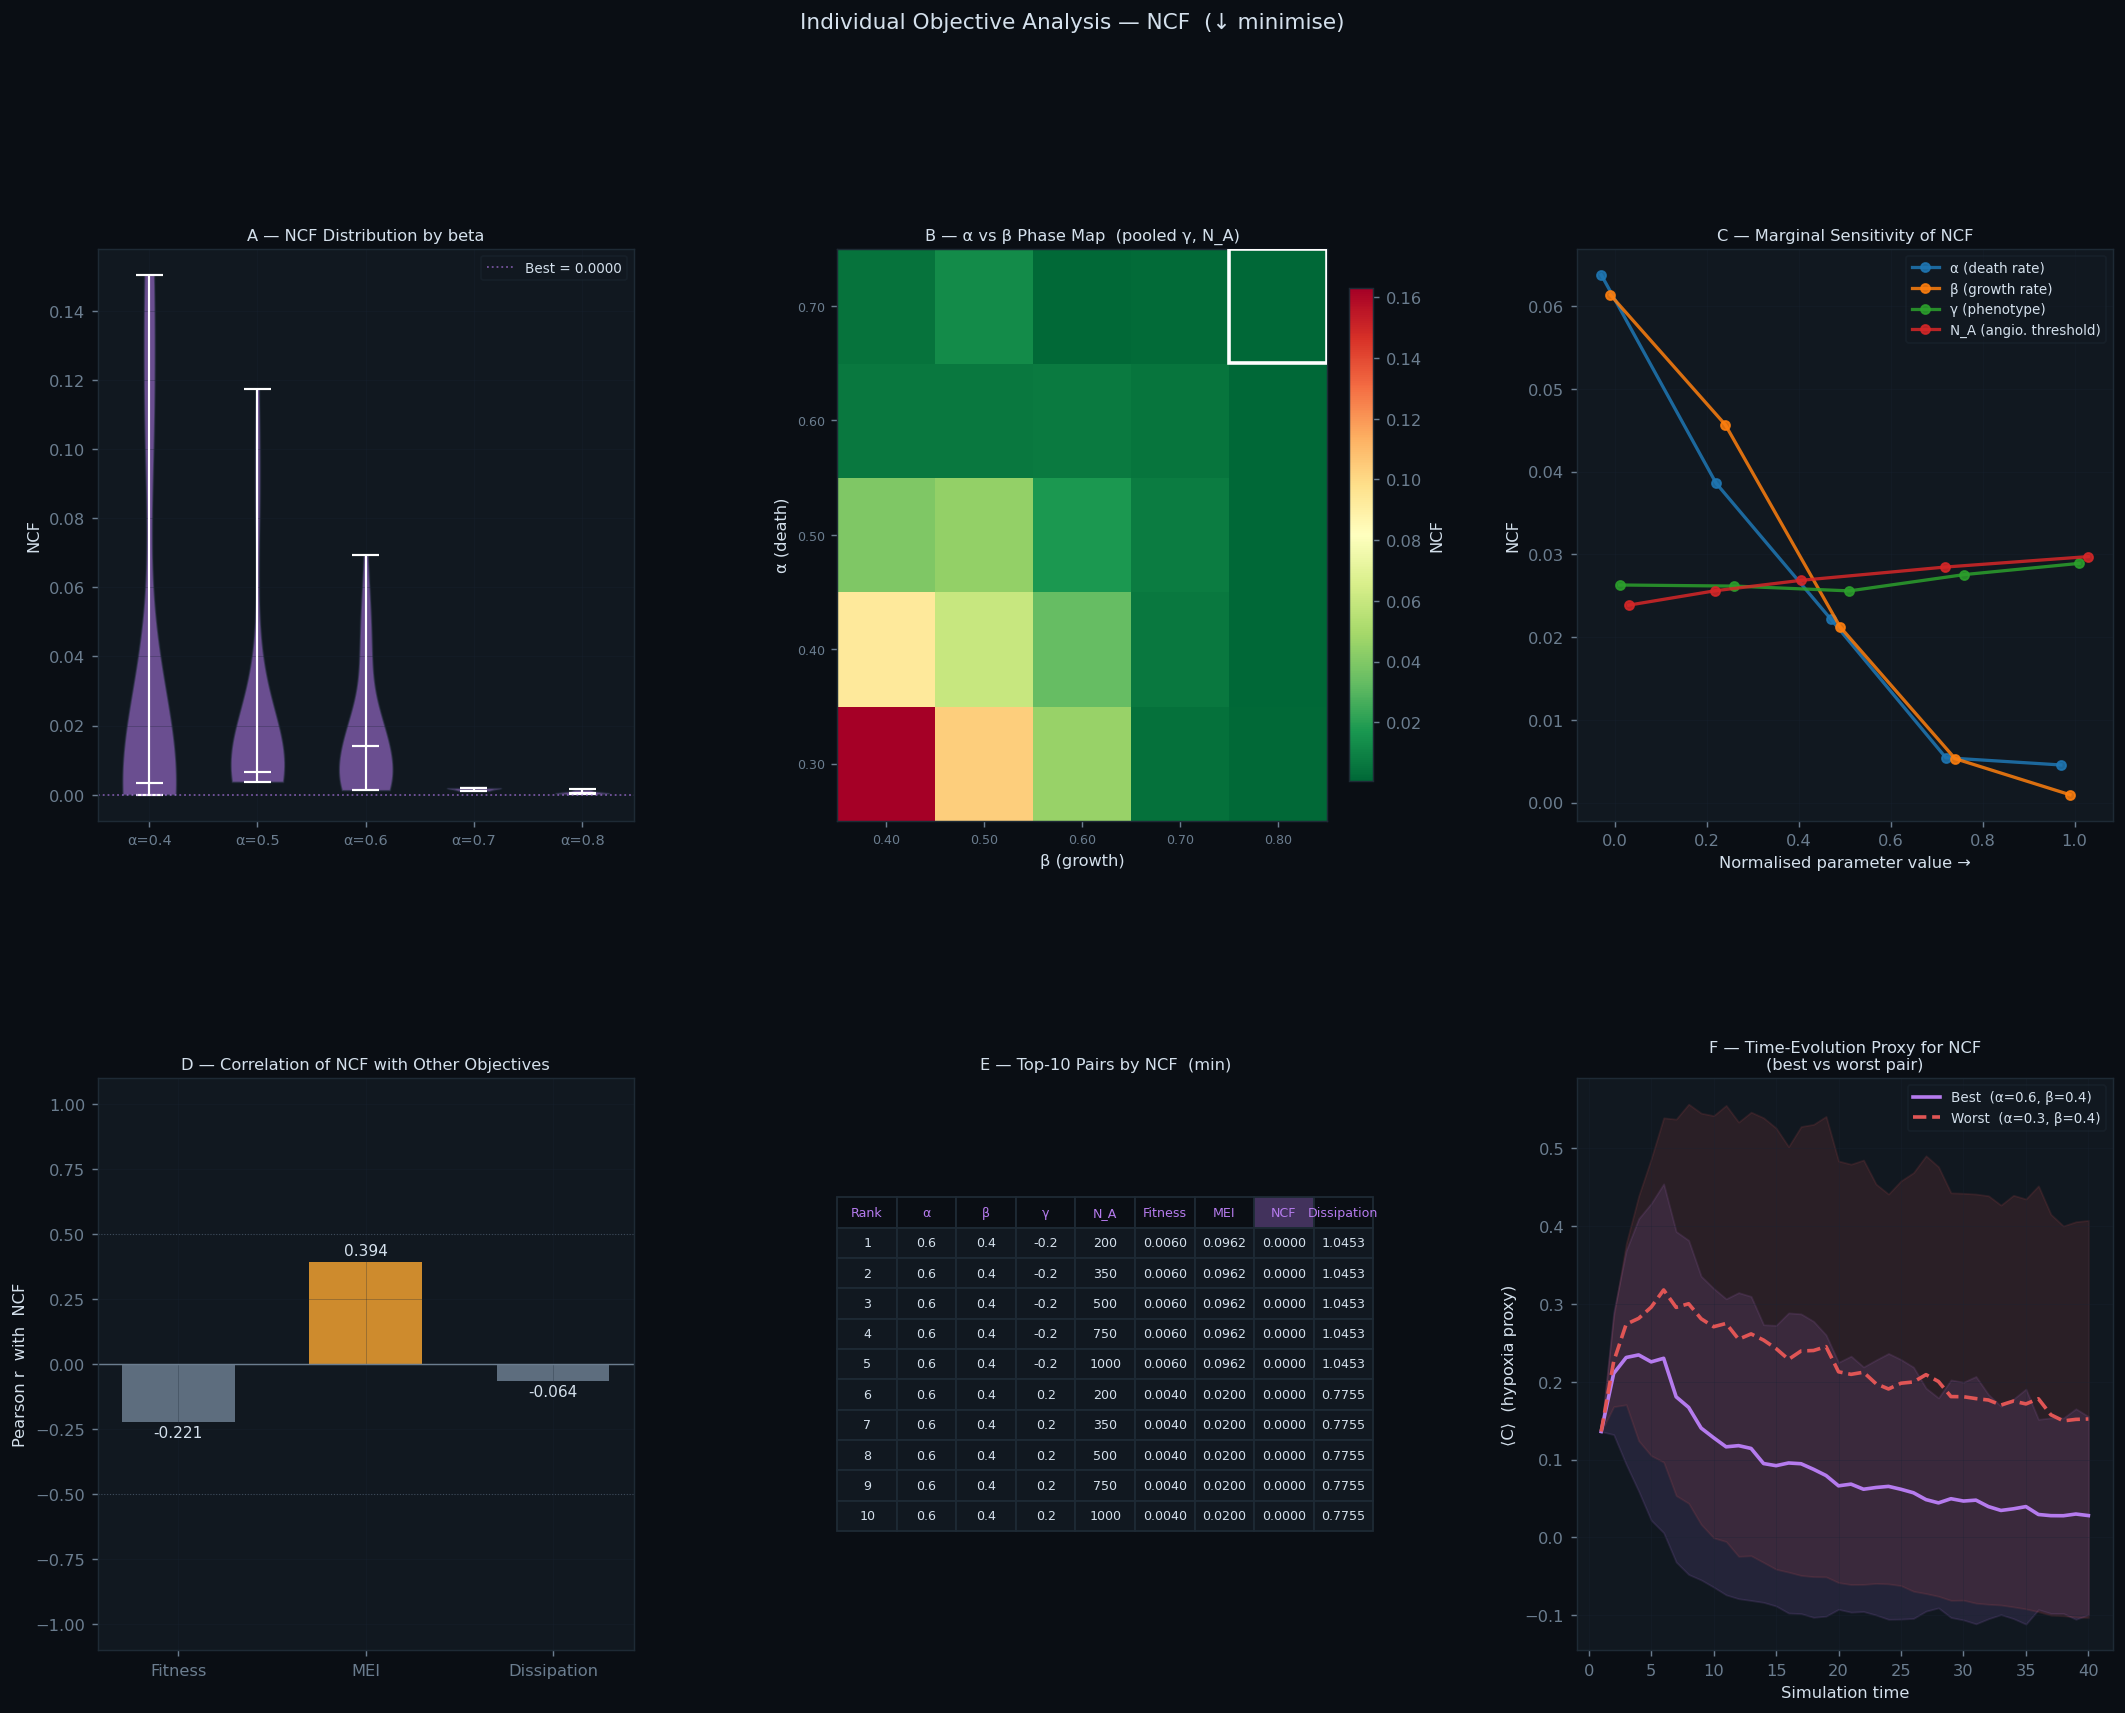

  Saved results\final-data\pareto_results\04_ncf.png
    04_dissipation.png …


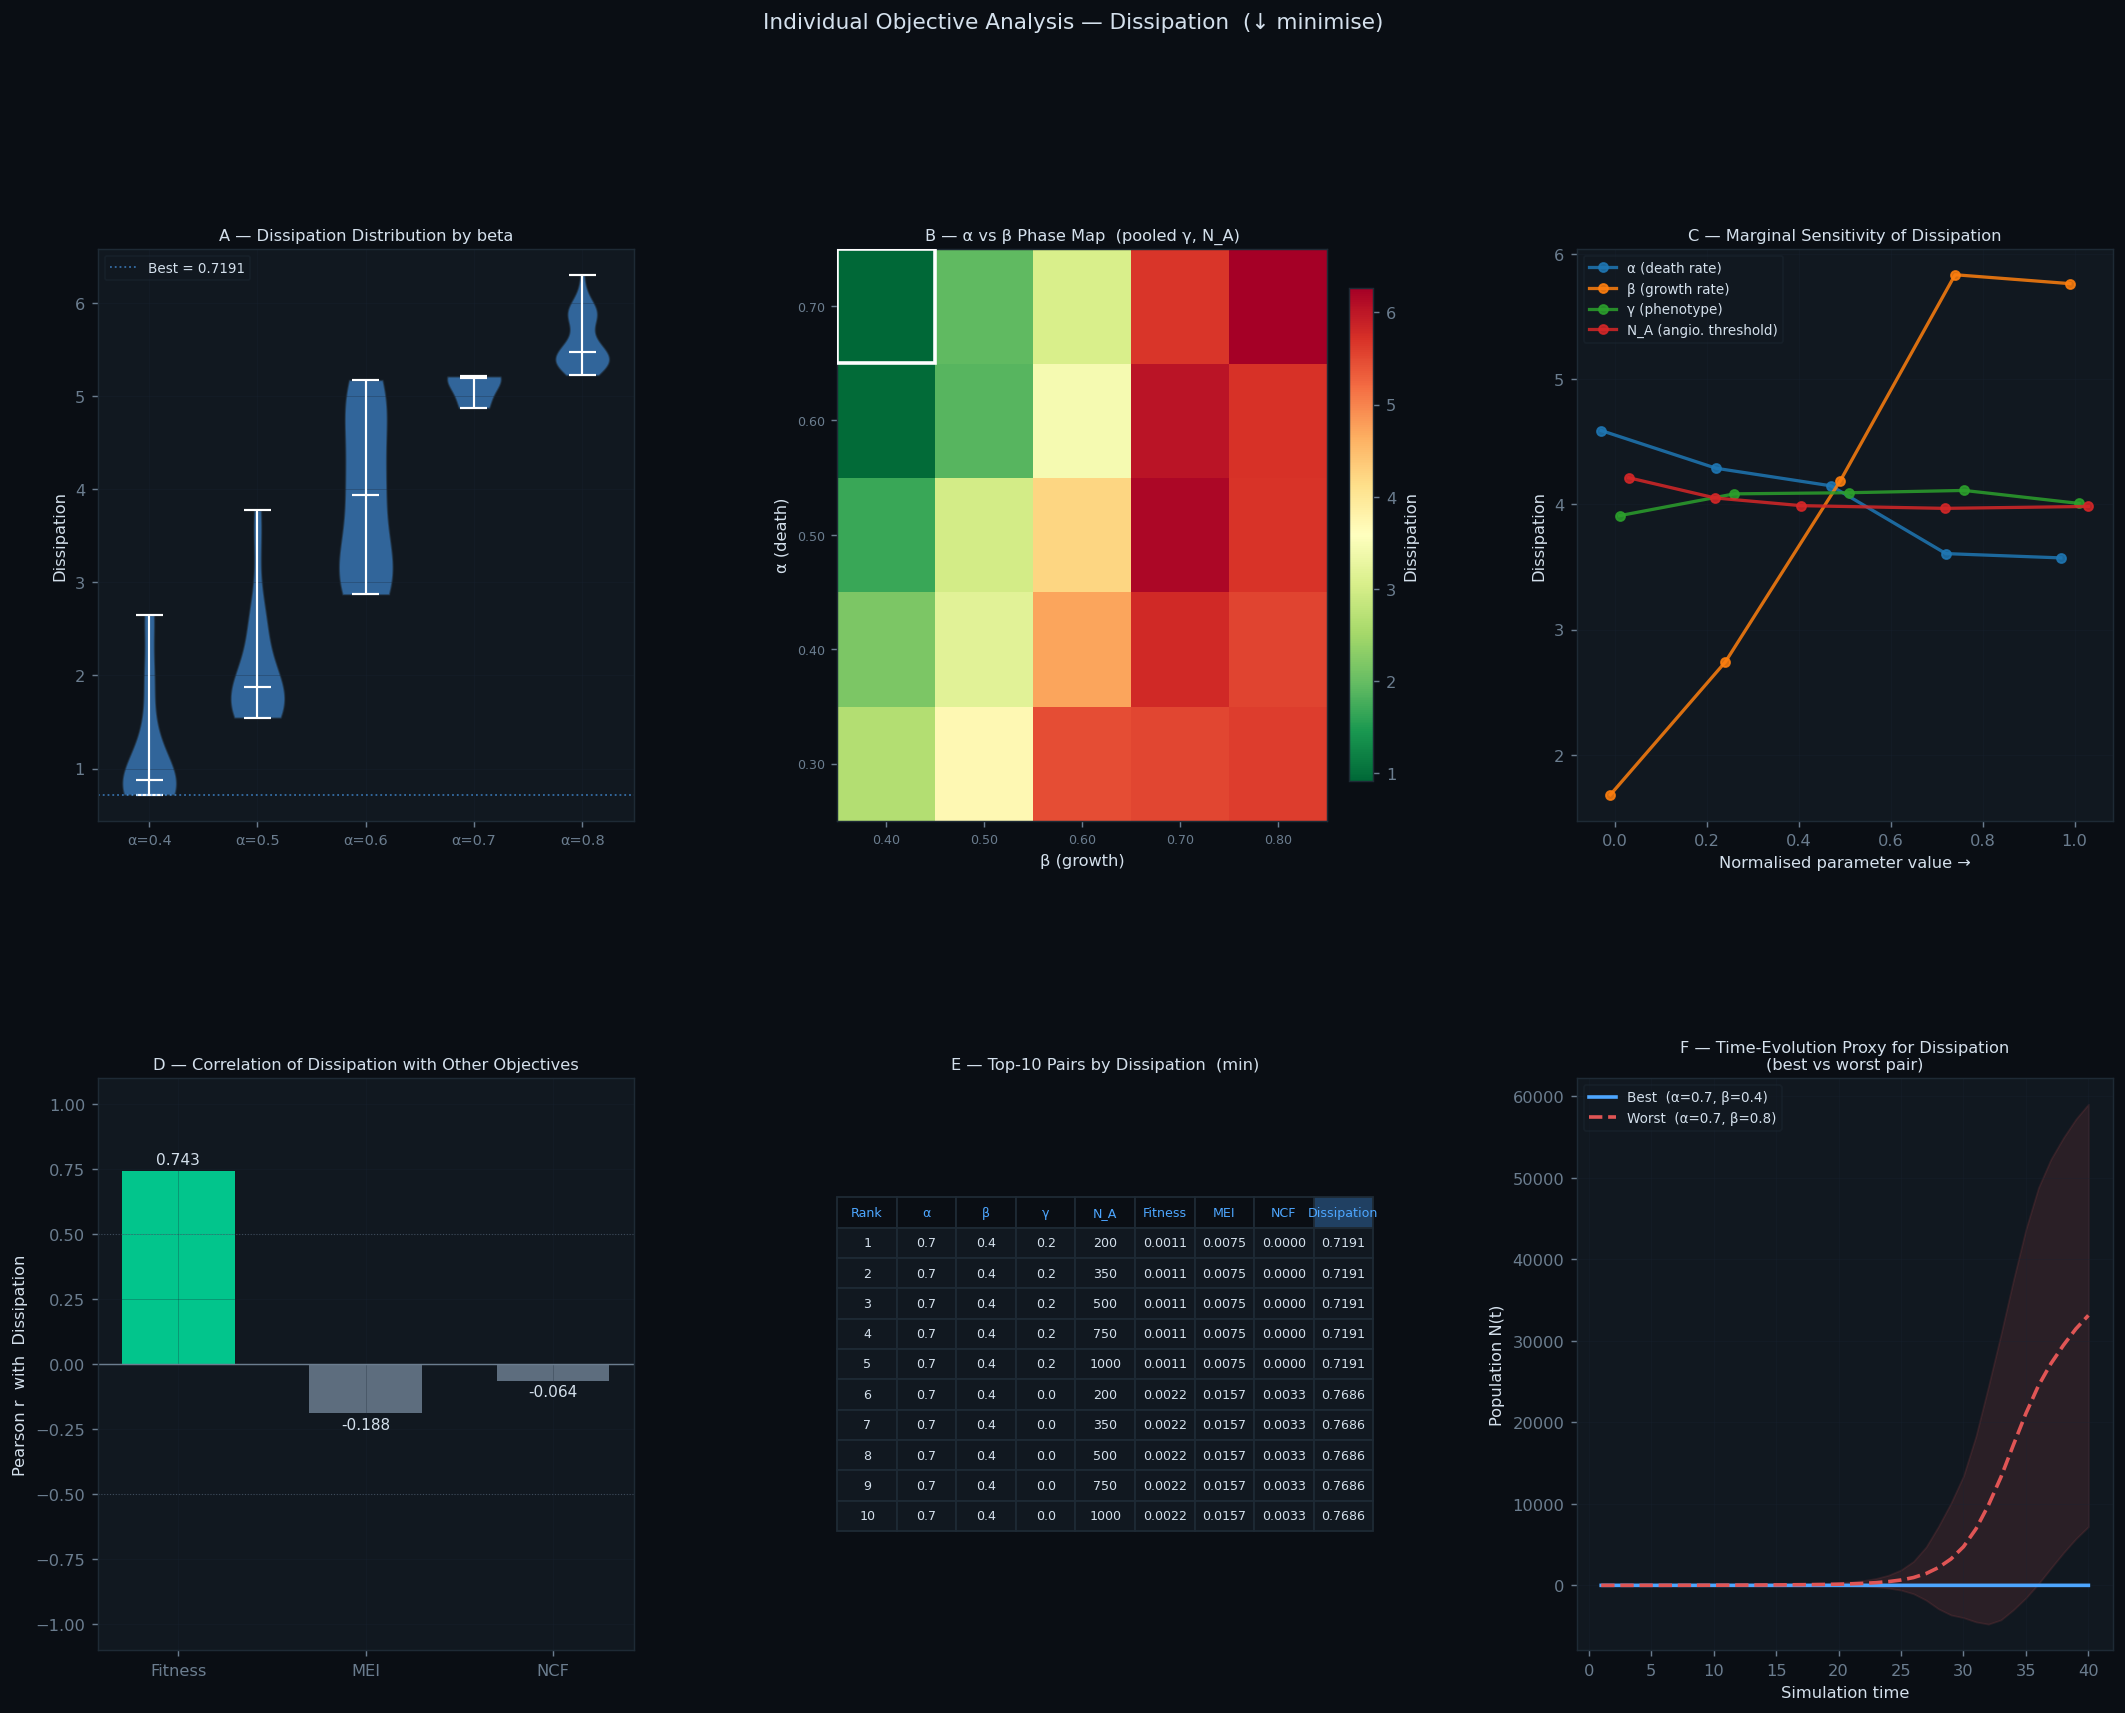

  Saved results\final-data\pareto_results\04_dissipation.png


In [54]:
print("  Fig 04 — Per-objective analyses")
fig_A01_to_A04(pf, front, run_ok)

  Fig 05 — Reduced 2D Pareto front


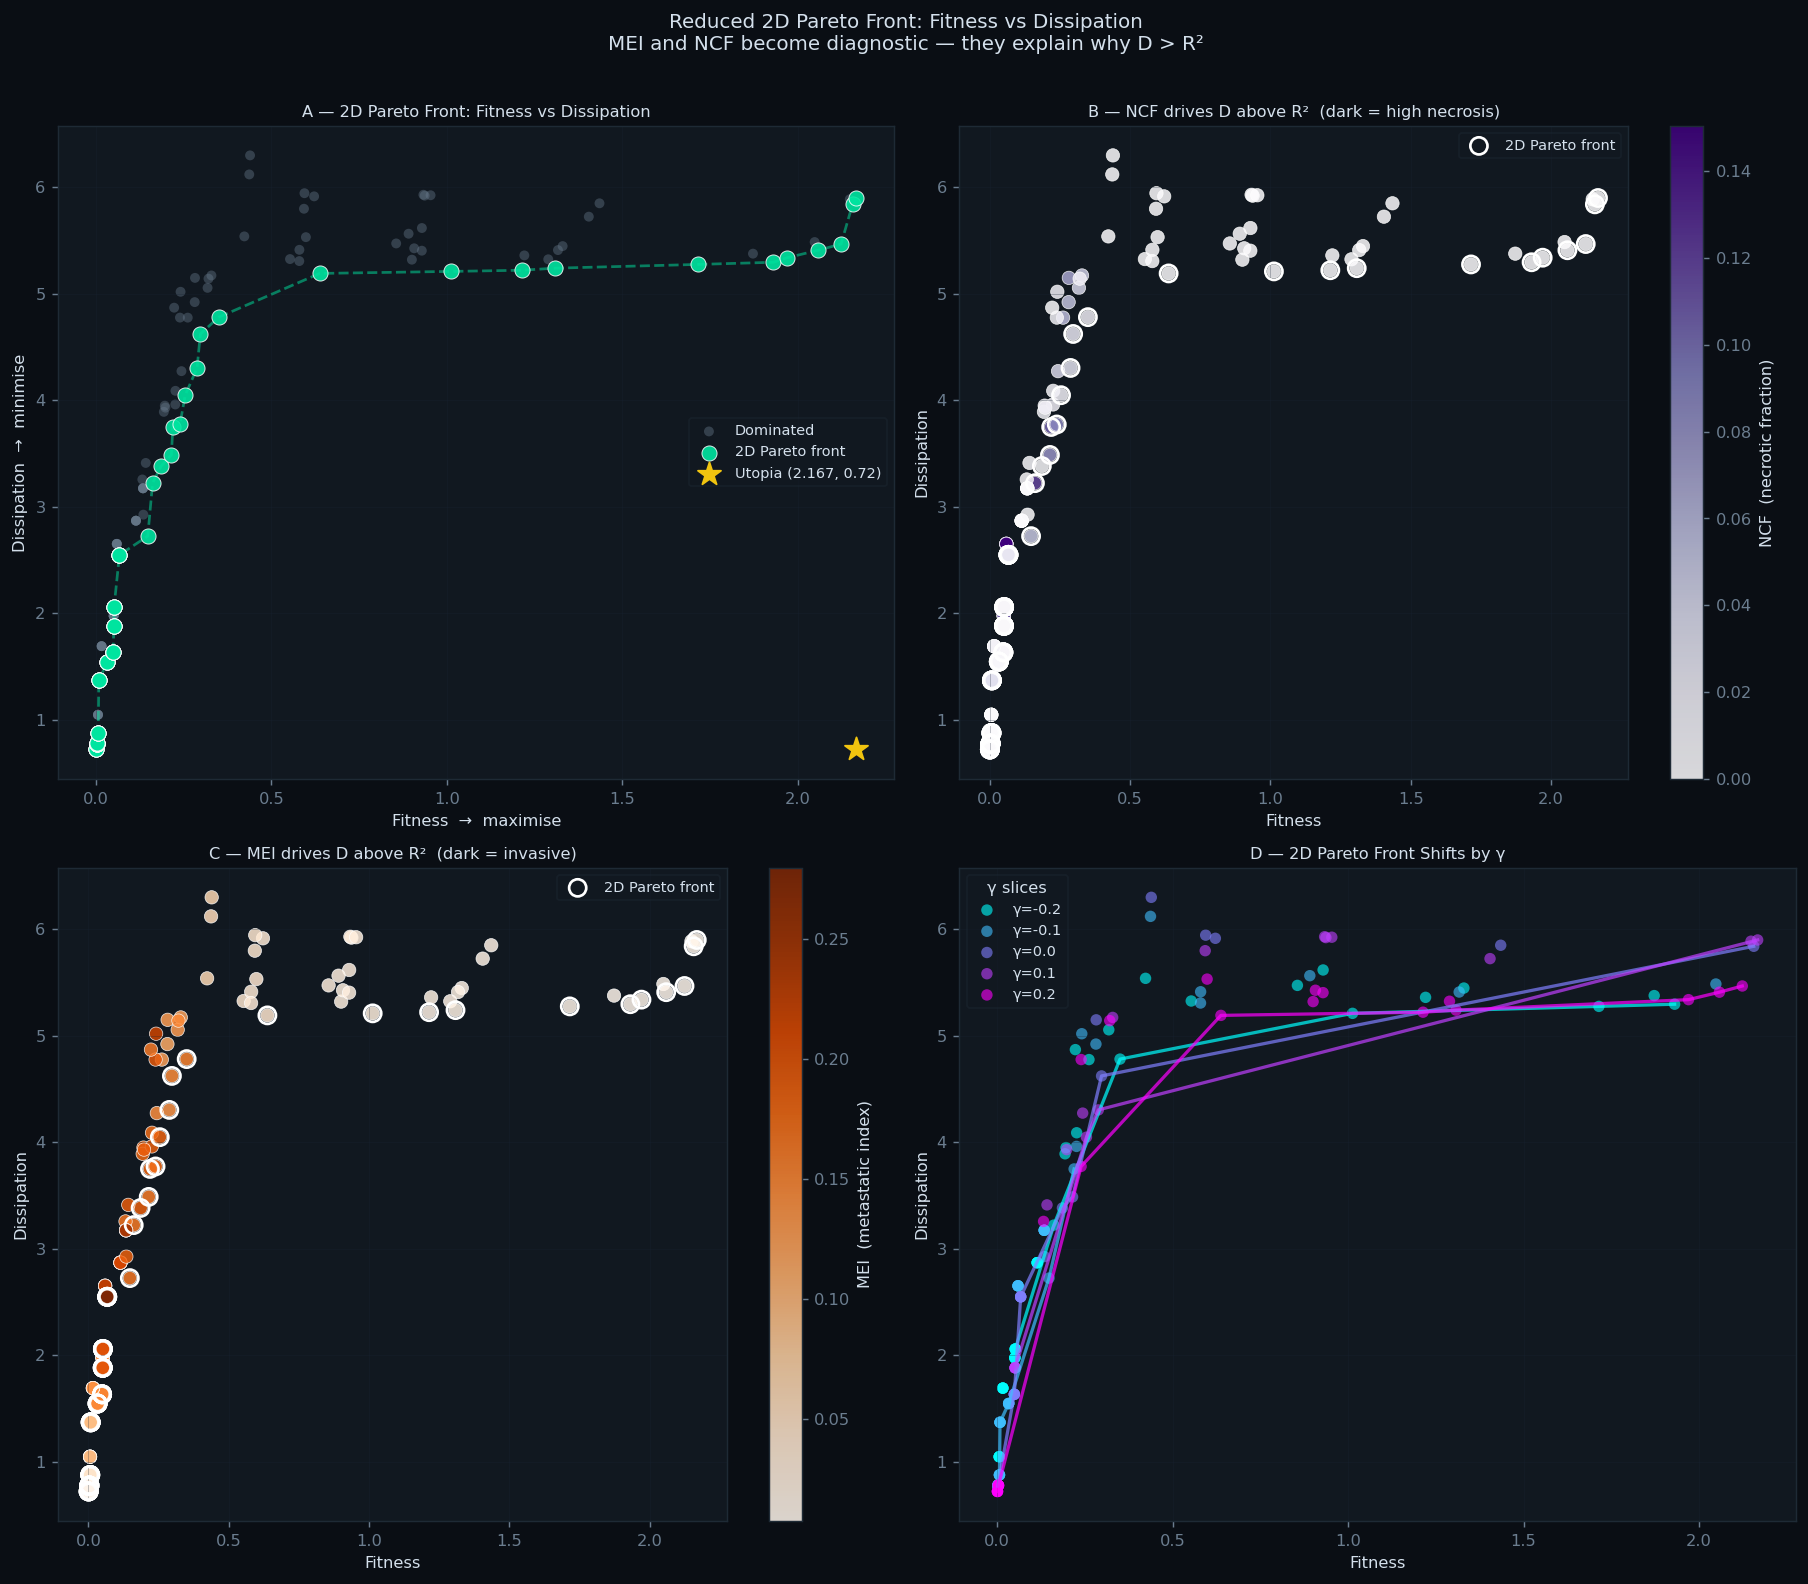

  Saved results\final-data\pareto_results\05_two_objective_pareto.png


In [55]:
print("  Fig 05 — Reduced 2D Pareto front")
fig_A05_two_objective_pareto(front)

  Fig 06 — Multi-objective convergence


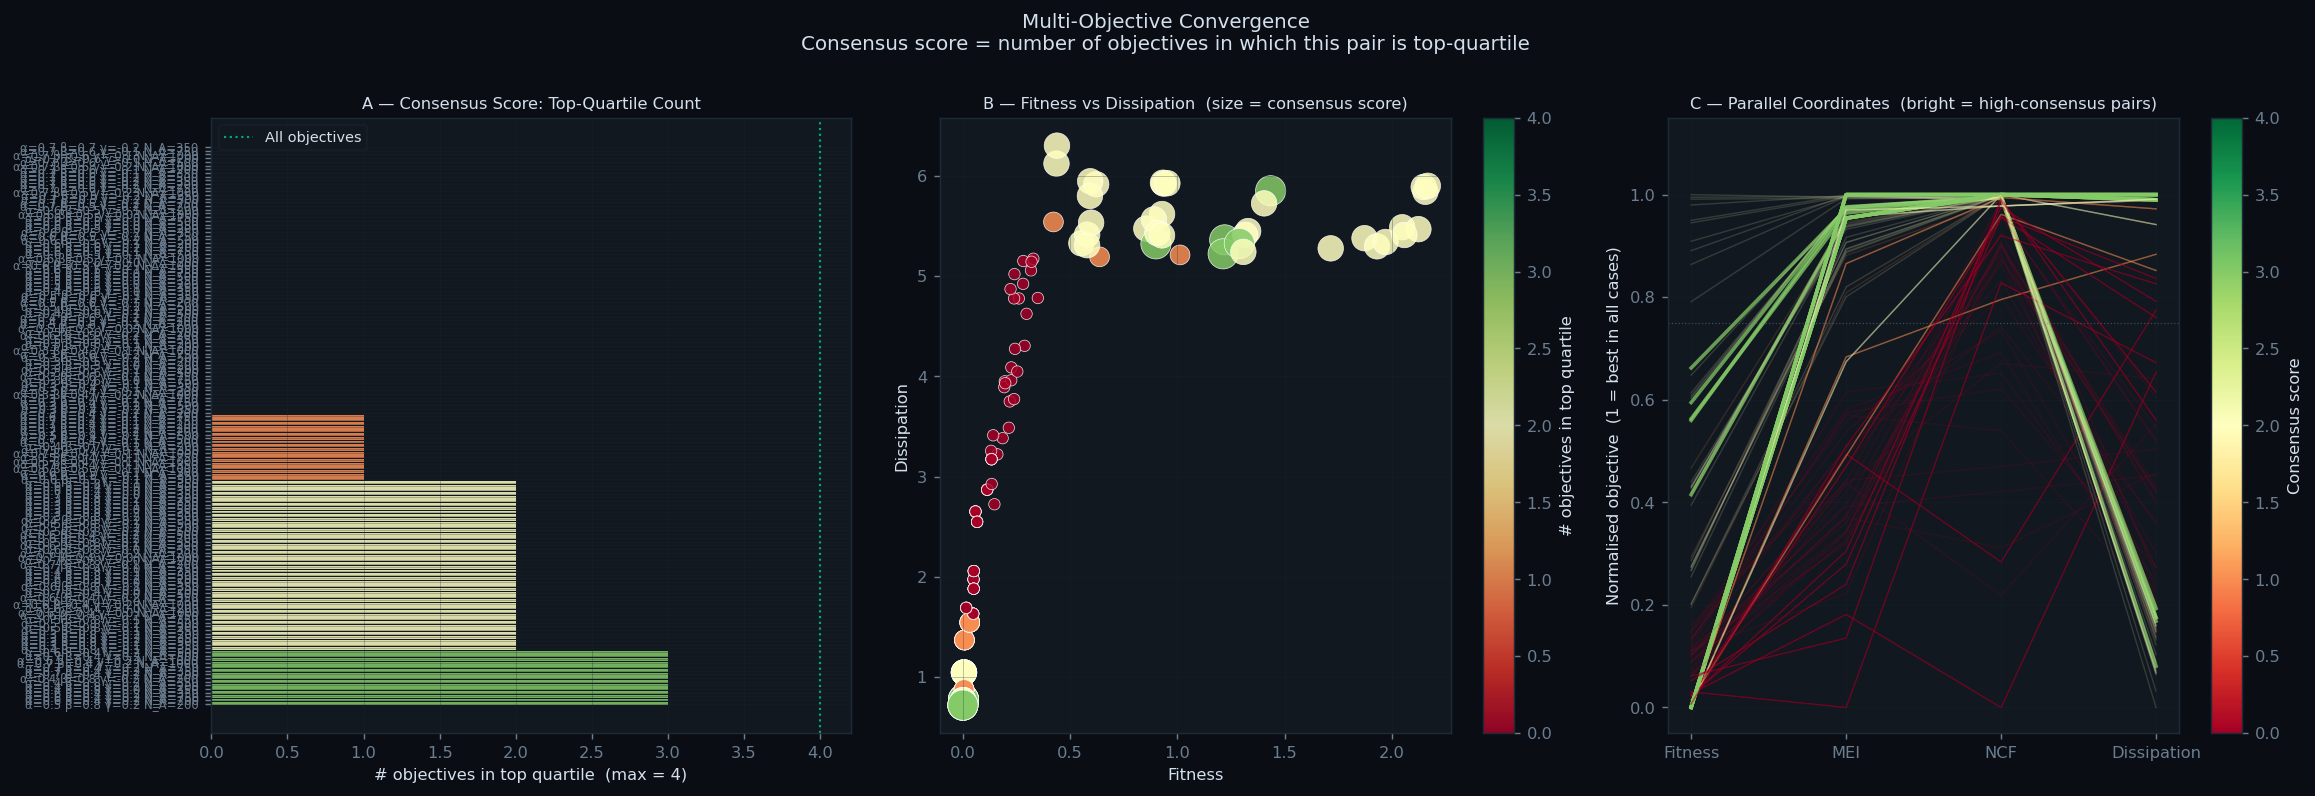

  Saved results\final-data\pareto_results\06_convergence.png


In [56]:
print("  Fig 06 — Multi-objective convergence")
fig_A06_convergence(pf, front)

In [57]:
print(f"\nDone.  All figures saved to ./{PLOT_DIR}/")


Done.  All figures saved to ./results/final-data/pareto_results/
